In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Сборка датасета

Скачаем необходимые датасеты

Тот который получается в результате eda


In [ ]:
doctors = pd.read_csv('https://github.com/yyaroslavskiy/cuddly-chainsaw/raw/refs/heads/develop/eda/doctors_eda_result.csv',encoding='utf-8')

In [ ]:
doctors

,Unnamed: 0,name,experience,rating_sber,review_count_sber,price_sber,link_sber,clinics_count_sber,clinic_1_name_sber,clinic_1_address_sber,...,comment_prod,doctor_source,experience_category,rating_sber_norm,rating,price,price_category_sber,price_category_prod,price_category_avg,price_tier
0,0,Абросимова Елена Владимировна,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,ProDoctorov,21-30 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Абросимова Елена Владимировна,32.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,ProDoctorov,Более 30 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Агеева Наталья Юрьевна,18.0,4.5,0.0,3500.0,https://docdoc.ru/doctor/Ageeva_Natalya_12,1.0,Будь Здоров на Рязанском проспекте,"г. Москва, ул. Рязанский пр-т, д. 2Б",...,NaN,SberHealth,16-20 лет,4.125,4.125000,3500.0,3k-5k,NaN,NaN,Средний
3,3,Агеева Наталья Юрьевна,NaN,4.0,0.0,NaN,https://docdoc.ru/doctor/Ageeva_Natalya_3,0.0,NaN,NaN,...,NaN,SberHealth,No value,3.250,3.250000,NaN,NaN,NaN,NaN,NaN
4,4,Акимова Анна Владимировна,18.0,4.3,0.0,NaN,https://docdoc.ru/doctor/Akimova_Anna_7,0.0,NaN,NaN,...,NaN,SberHealth,16-20 лет,3.775,3.775000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38860,38860,Ященко Елена Николаевна,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.0,ProDoctorov,No value,NaN,0.339583,3535.0,NaN,3k-5k,NaN,Средний
38861,38861,Ященко Ирина Анатольевна,30.0,4.7,2.0,NaN,https://docdoc.ru/doctor/Yashtenko_Irina,0.0,NaN,NaN,...,NaN,Обе платформы,21-30 лет,4.475,2.303125,NaN,NaN,NaN,NaN,NaN
38862,38862,Ящина Ольга Владимировна,NaN,4.0,3.0,NaN,https://docdoc.ru/doctor/Yashtina_Olga,0.0,NaN,NaN,...,1.0,Обе платформы,No value,3.250,2.828947,NaN,NaN,NaN,NaN,NaN
38863,38863,Ящук Сергей Борисович,41.0,4.3,3.0,NaN,https://docdoc.ru/doctor/Yashtuk_Sergey,0.0,NaN,NaN,...,3.0,Обе платформы,Более 30 лет,3.775,4.226501,NaN,NaN,NaN,NaN,NaN


In [ ]:
del doctors['Unnamed: 0']

In [ ]:
doctors_reviews = pd.read_csv('https://github.com/yyaroslavskiy/cuddly-chainsaw/raw/refs/heads/develop/eda/merge/doctors_review.csv')

In [ ]:
del doctors_reviews['Unnamed: 0']

Из временной памяти коллаба, можно заменить

In [ ]:
unique_addresses_with_coords = pd.read_csv('https://github.com/yyaroslavskiy/cuddly-chainsaw/raw/refs/heads/develop/parsing/api_yandex_geocoder/api_addresses.csv')

In [ ]:
unique_addresses_with_coords

,level_0,address,address_norm,latitude,longitude,district,area,index
0,63210,"г. Москва, ул. Рязанский пр-т, д. 2Б","г. москва, улица рязанский пр-т, д. 2б",55.730487,37.738656,Нижегородский район,Юго-Восточный административный округ,43404.0
1,63211,"г. Москва, ул. Щукинская, д. 2","г. москва, улица щукинская, д. 2",55.809641,37.481936,район Щукино,Северо-Западный административный округ,43405.0
2,63212,"г. Москва, Последний пер., д. 28","г. москва, последний переулок, д. 28",55.769681,37.630625,Мещанский район,Центральный административный округ,43406.0
3,63213,"г. Москва, ул. Нагорная, д. 17, корп. 6","г. москва, улица нагорная, д. 17, корпус 6",55.677524,37.607709,район Котловка,Юго-Западный административный округ,43407.0
4,63214,"г. Тверь, ул. Крылова, д. 21","г. тверь, улица крылова, д. 21",NaN,NaN,NaN,NaN,43408.0
...,...,...,...,...,...,...,...,...
4744,67954,"Электролитный проезд, д. 16, корп. 2","электролитный проезд, д. 16, корпус 2",55.671280,37.611024,Нагорный район,Южный административный округ,64195.0
4745,67955,"Верея, пл. Советская, д. 1","верея, площадь советская, д. 1",NaN,NaN,NaN,NaN,64196.0
4746,67956,"ул. Люсиновская, д. 36, стр. 2","улица люсиновская, д. 36, стр 2",55.722852,37.620501,район Замоскворечье,Центральный административный округ,64197.0
4747,67957,"Котельники, ул. Кузьминская, д. 7Б","котельники, улица кузьминская, д. 7б",55.665274,37.867529,NaN,NaN,64198.0


In [ ]:
mean_review_rate = pd.read_csv('https://github.com/yyaroslavskiy/cuddly-chainsaw/raw/refs/heads/develop/eda/review_stat.csv')

In [ ]:
mean_review_rate

,doctor_link,rate,comment,source
0,https://docdoc.ru/doctor/ALEKSANDROVA_LYuDMILA_5,4.850000,20,sber
1,https://docdoc.ru/doctor/ARISTARHOVA_NADEZhDA,5.000000,3,sber
2,https://docdoc.ru/doctor/ASTAPOVICh_NATALYa_2,5.000000,4,sber
3,https://docdoc.ru/doctor/Aakef_Hayder,5.000000,3,sber
4,https://docdoc.ru/doctor/Abacheva_Maida,5.000000,19,sber
...,...,...,...,...
33155,https://prodoctorov.ru/moskva/vrach/999665-saa...,4.933333,3,prodoctorov
33156,https://prodoctorov.ru/moskva/vrach/999727-ved...,5.000000,1,prodoctorov
33157,https://prodoctorov.ru/moskva/vrach/999733-dzh...,5.000000,3,prodoctorov
33158,https://prodoctorov.ru/moskva/vrach/999782-fed...,5.000000,3,prodoctorov


Соберем датасет для анализа.

Из doctors.csv возьмем комбинацию имя доктора-клиника, добавим ссылку, рейтинг, цену с одного ресурса и если есть среднюю, опыт, метро, специальности, с кем работает (дети/взрослые),

из датасета с географией - координаты, район и административный округ,

из датасета с отзывами - среднюю оценку из отзывов

In [ ]:
address_records = []

#проходимся по адресам сбера для каждого врача чтобы собрать детальную инфу по каждому адресу
for i in [1, 2, 3]:
    sber_mask = doctors[f'clinic_{i}_address_sber'].notna()
    for idx, row in doctors[sber_mask].iterrows():
        adress_match = unique_addresses_with_coords[unique_addresses_with_coords['address'] == row[f'clinic_{i}_address_sber']]
        review_match = mean_review_rate[mean_review_rate['doctor_link']==row['link_sber']]
        address_records.append({
            'address': row[f'clinic_{i}_address_sber'],
            'source': 'sber',
            'doctor_name': row['name'],
            'doctor_link' : row['link_sber'],
            'rating': row['rating'],
            'price_source': row['price_sber'],
            'price_avg': row['price'],
            'experience': row['experience'],
            'metro' : row[f'clinic_{i}_metro_sber'],
            'speciality' : row['speciality'],
            'is_kids' : row['is_kids'],
            'is_adults' : row['is_adults'],
            'latitude': adress_match['latitude'].iloc[0] if not adress_match.empty else None,
            'longitude': adress_match['longitude'].iloc[0] if not adress_match.empty else None,
            'review_rating': review_match['rate'].iloc[0] if not review_match.empty else None,
            'district': adress_match['district'].iloc[0] if not adress_match.empty else None,
            'area': adress_match['area'].iloc[0] if not adress_match.empty else None
        })


#проходимся по адресам продокторов для каждого врача
for i in [1, 2, 3]:
    prod_mask = doctors[f'clinic_{i}_address_prod'].notna()
    for idx, row in doctors[prod_mask].iterrows():
        adress_match = unique_addresses_with_coords[unique_addresses_with_coords['address'] == row[f'clinic_{i}_address_prod']]
        review_match = mean_review_rate[mean_review_rate['doctor_link']==row['link_prod']]
        address_records.append({
            'address': row[f'clinic_{i}_address_prod'],
            'source': 'prod',
            'doctor_name': row['name'],
            'doctor_link' : row['link_prod'],
            'rating': row['rating'],
            'price_source': row['price_prod'],
            'price_avg': row['price'],
            'experience': row['experience'],
            'metro' : row[f'clinic_{i}_metro_prod'],
            'speciality' : row['speciality'],
            'is_kids' : row['is_kids'],
            'is_adults' : row['is_adults'],
            'latitude': adress_match['latitude'].iloc[0] if not adress_match.empty else None,
            'longitude': adress_match['longitude'].iloc[0] if not adress_match.empty else None,
            'review_rating': review_match['rate'].iloc[0]if not review_match.empty else None,
            'district': adress_match['district'].iloc[0] if not adress_match.empty else None,
            'area': adress_match['area'].iloc[0] if not adress_match.empty else None
        })

data_coords = pd.DataFrame(address_records)

In [ ]:
data_coords

,address,source,doctor_name,doctor_link,rating,price_source,price_avg,experience,metro,speciality,is_kids,is_adults,latitude,longitude,review_rating,district,area
0,"г. Москва, ул. Рязанский пр-т, д. 2Б",sber,Агеева Наталья Юрьевна,https://docdoc.ru/doctor/Ageeva_Natalya_12,4.125000,3500.0,3500.0,18.0,Нижегородская,NaN,False,True,55.730487,37.738656,NaN,Нижегородский район,Юго-Восточный административный округ
1,"г. Москва, ул. Щукинская, д. 2",sber,Алексеева Екатерина Михайловна,https://docdoc.ru/doctor/Alekseeva_Ekaterina_36,4.540625,5000.0,5000.0,11.0,Щукинская,NaN,False,True,55.809641,37.481936,5.0,район Щукино,Северо-Западный административный округ
2,"г. Москва, Последний пер., д. 28",sber,Антипова Анна Дмитриевна,https://docdoc.ru/doctor/Antipova_Anna_12,3.775000,5500.0,5500.0,4.0,Сухаревская,невролог,False,True,55.769681,37.630625,NaN,Мещанский район,Центральный административный округ
3,"г. Москва, ул. Нагорная, д. 17, корп. 6",sber,Аранович Элина Викторовна,https://docdoc.ru/doctor/Elina_Viktorovna,4.606250,6900.0,6900.0,23.0,Нагорная,NaN,False,True,55.677524,37.607709,5.0,район Котловка,Юго-Западный административный округ
4,"г. Тверь, ул. Крылова, д. 21",sber,Барбашинова Юлия Владимировна,https://docdoc.ru/doctor/Barbashinova_Yuliya,4.540625,15000.0,15000.0,25.0,NaN,NaN,True,True,NaN,NaN,5.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42307,"Котельники, ул. Кузьминская, д. 7Б",prod,Ярусова Инна Викторовна,https://prodoctorov.ru/moskva/vrach/316879-yar...,4.540625,NaN,NaN,33.0,Котельники,терапевт,False,True,55.665274,37.867529,NaN,NaN,NaN
42308,"ул. Энгельса, д. 7/21",prod,Ярцева Ирина Михайловна,https://prodoctorov.ru/moskva/vrach/289003-yar...,4.790000,10000.0,10000.0,19.0,Бауманская,"терапевт, аллерголог",False,True,NaN,NaN,5.0,NaN,NaN
42309,"Реутов, Юбилейный просп., д. 80",prod,Ясинская Светлана Борисовна,https://prodoctorov.ru/moskva/vrach/865955-yas...,4.540625,NaN,NaN,27.0,Новокосино,эндокринолог,False,True,55.753068,37.887884,NaN,10-й микрорайон,NaN
42310,"Махачкала, ул. Ахульго, д. 8",prod,Яхьяева Байсари Исаковна,https://prodoctorov.ru/moskva/vrach/997474-yah...,3.494306,1120.0,1560.0,32.0,NaN,гинеколог,False,True,NaN,NaN,5.0,NaN,NaN


In [ ]:
data_coords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42312 entries, 0 to 42311
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   address        42312 non-null  object 
 1   source         42312 non-null  object 
 2   doctor_name    42312 non-null  object 
 3   doctor_link    42312 non-null  object 
 4   rating         39686 non-null  float64
 5   price_source   15720 non-null  float64
 6   price_avg      16613 non-null  float64
 7   experience     28416 non-null  float64
 8   metro          39722 non-null  object 
 9   speciality     41321 non-null  object 
 10  is_kids        42312 non-null  bool   
 11  is_adults      42312 non-null  bool   
 12  latitude       39222 non-null  float64
 13  longitude      39222 non-null  float64
 14  review_rating  32203 non-null  float64
 15  district       13930 non-null  object 
 16  area           13503 non-null  object 
dtypes: bool(2), float64(7), object(8)
memory usage: 4.

In [ ]:
data_coords.describe()

,rating,price_source,price_avg,experience,latitude,longitude,review_rating
count,39686.000000,15720.000000,16613.000000,28416.000000,39222.000000,39222.000000,32203.000000
mean,3.433103,4740.573664,4778.155451,21.496340,55.737611,37.589520,4.409785
std,1.193812,3798.333502,3821.263525,12.225403,0.086107,0.139541,1.155673
min,0.000000,500.000000,500.000000,1.000000,55.099778,36.461908,0.000000
25%,2.750000,2900.000000,2900.000000,11.000000,55.685046,37.510448,4.375000
50%,3.641492,3500.000000,3600.000000,20.000000,55.744054,37.593075,5.000000
75%,4.372880,5500.000000,5450.000000,30.000000,55.786693,37.658742,5.000000
max,5.000000,150000.000000,150000.000000,71.000000,56.296939,38.275454,5.000000


In [ ]:
data_coords = data_coords.dropna(subset= 'latitude')

In [ ]:
data_coords= data_coords.drop_duplicates()

## Карты

### Визуализация Москвы

In [ ]:
sns.set(style='darkgrid')

Выставим границы для координат, чтобы получить только московские адреса


In [ ]:
data_moskow = data_coords[(data_coords['latitude']<55.931762) & (data_coords['latitude']>55.545493) & (data_coords['longitude']>37.344287) & (data_coords['longitude']<37.879998)]

In [ ]:
data_moskow.to_csv('data_moskow.csv')

In [ ]:
data_moskow = pd.read_csv('/content/data_moskow.csv')

/tmp/ipython-input-55760830.py:3: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.



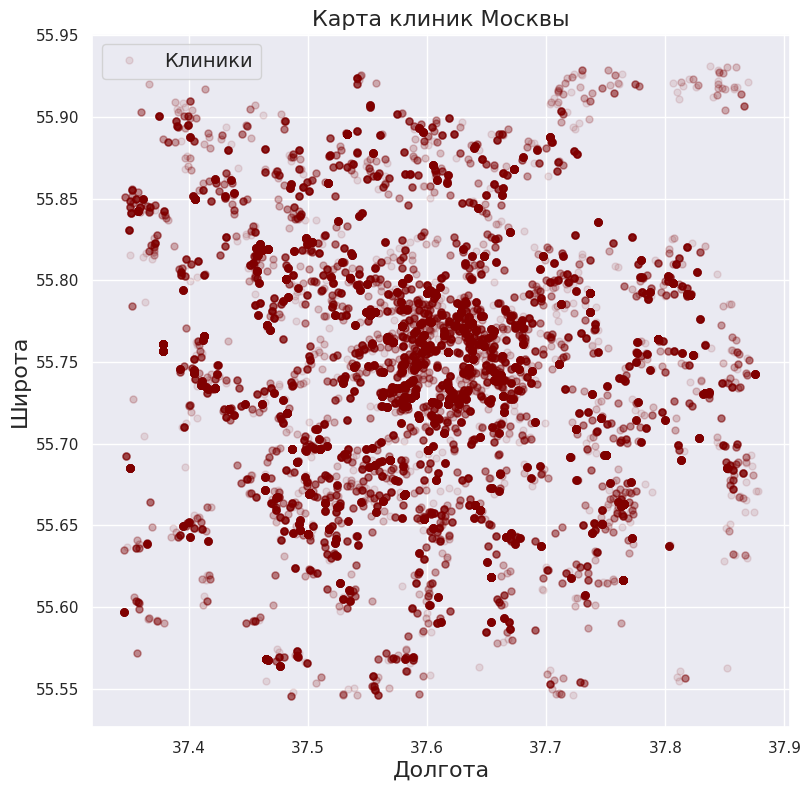

In [ ]:
plt.figure(figsize=(9, 9))

plt.plot(data_moskow['longitude'], data_moskow['latitude'], 'ro', label='Клиники', alpha=0.1, color='maroon', markersize=5)

plt.xlabel('Долгота', fontsize=16)
plt.ylabel('Широта', fontsize=16)
plt.title('Карта клиник Москвы', fontsize=16)
plt.legend(fontsize=14, frameon=True)

# скачать изображение с прозрачным фоном
# plt.savefig('card_base.png', transparent=True)
plt.show()

границы москвы с сопоставлением с реальной картой

In [ ]:
data_moskow[(data_moskow['latitude']<55.58)&(data_moskow['longitude']<37.4)|(data_moskow['latitude']>55.92)&(data_moskow['longitude']>37.86)]

,Unnamed: 0,address,source,doctor_name,doctor_link,rating,price_source,price_avg,experience,metro,speciality,is_kids,is_adults,latitude,longitude,review_rating,district,area
455,475,"г. Королёв, ул. пр-т Космонавтов, д. 3Б",sber,Беженар Владимир Афанасьевич,https://docdoc.ru/doctor/Bezhenar_Vladimir,4.291250,NaN,3000.0,20.0,NaN,"андролог, онколог-уролог, уролог, врач узи, он...",False,True,55.921228,37.869631,4.625,исторический район Костино,NaN
11074,12248,"пос. Валуево, стр. 2",prod,Джуракулов Бобокалон Равшанович,https://prodoctorov.ru/moskva/vrach/994188-dzh...,2.482996,NaN,NaN,NaN,Филатов луг,"рефлексотерапевт, невролог",False,True,55.571714,37.356486,5.000,NaN,NaN
17499,19597,"пос. Валуево, стр. 2",prod,Матвеева Марина Викторовна,https://prodoctorov.ru/moskva/vrach/994196-mat...,3.250000,NaN,NaN,NaN,Филатов луг,невролог,False,True,55.571714,37.356486,NaN,NaN,NaN
20922,23506,"пос. Валуево, стр. 2",prod,Прошкина Ирина Николаевна,https://prodoctorov.ru/moskva/vrach/994186-pro...,3.775000,NaN,NaN,NaN,Филатов луг,"физиотерапевт, невролог",False,True,55.571714,37.356486,NaN,NaN,NaN
27893,31521,"пос. Валуево, стр. 2",prod,Андрощук Сергей Николаевич,https://prodoctorov.ru/moskva/vrach/994185-and...,3.950000,NaN,NaN,36.0,Филатов луг,"терапевт, врач узи",False,True,55.571714,37.356486,NaN,NaN,NaN
32505,37260,"пос. Валуево, стр. 2",prod,Реут Юлия Сергеевна,https://prodoctorov.ru/moskva/vrach/852891-reut/,3.168558,NaN,NaN,17.0,Филатов луг,"функциональный диагност, кардиолог",False,True,55.571714,37.356486,5.000,NaN,NaN


## Карты по округам

### Визуализация округов

In [ ]:
data_moskow['area'].unique()

array(['Юго-Восточный административный округ',
       'Северо-Западный административный округ',
       'Центральный административный округ',
       'Юго-Западный административный округ',
       'Южный административный округ', 'Северный административный округ',
       'Северо-Восточный административный округ',
       'Западный административный округ',
       'Восточный административный округ', nan, 'Ошибка'], dtype=object)

In [ ]:
data_moskow['district'].unique()

array(['Нижегородский район', 'район Щукино', 'Мещанский район',
       'район Котловка', 'район Москворечье-Сабурово', 'район Аэропорт',
       'район Отрадное', 'район Ховрино', 'район Солнцево',
       'район Дорогомилово', 'район Лефортово', 'район Марьина Роща',
       'район Проспект Вернадского', 'район Арбат', 'район Беговой',
       'район Черёмушки', 'район Кунцево', 'Таганский район',
       'Тверской район', 'Головинский район', 'район Раменки',
       'район Якиманка', 'район Нагатинский Затон',
       'Красносельский район', 'Пресненский район',
       'район Орехово-Борисово Северное', 'район Коньково',
       'район Соколиная Гора', 'район Хамовники',
       'район Тропарёво-Никулино', 'Войковский район',
       'район Северное Бутово', 'Южнопортовый район', 'Нагорный район',
       nan, 'Хорошёвский район', 'район Новокосино', 'район Левобережный',
       'Даниловский район', 'Алексеевский район', 'район Замоскворечье',
       'Гагаринский район', 'Донской район', 'рай

In [ ]:
data_moskow=data_moskow.replace('Ошибка',np.nan)

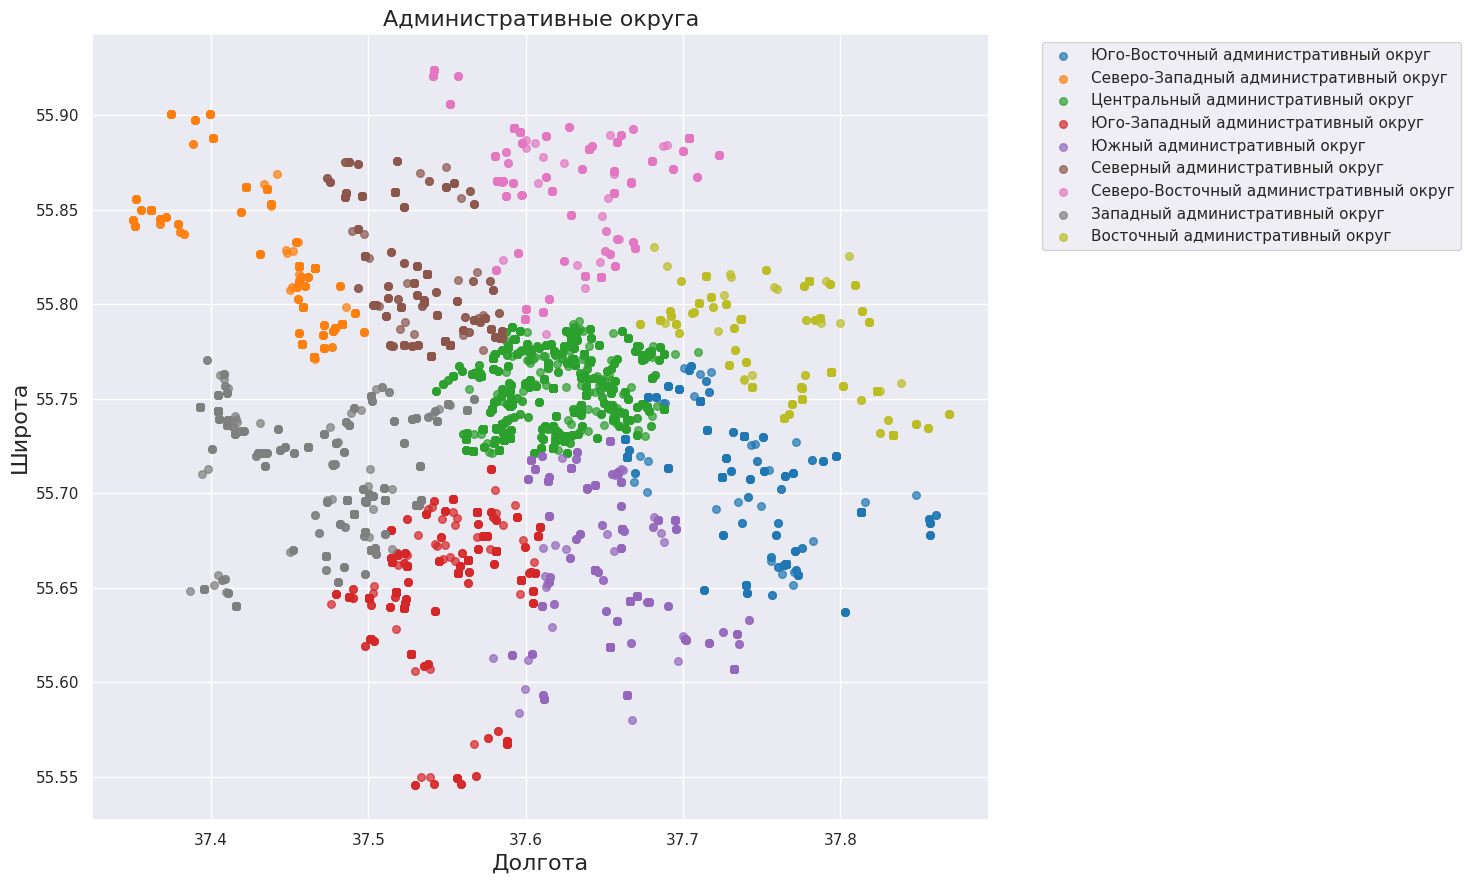

In [ ]:
plt.figure(figsize=(15, 9))
unique_areas = data_moskow['area'].dropna().nunique()

for i, area in enumerate(data_moskow['area'].dropna().unique()):
    area_data = data_moskow[data_moskow['area'] == area]
    plt.scatter(area_data['longitude'], area_data['latitude'],
                   color=plt.cm.tab10(i/unique_areas), label=area, alpha=0.7, s=30)

plt.xlabel('Долгота', fontsize=16)
plt.ylabel('Широта', fontsize=16)
plt.title('Административные округа', fontsize=16)

# Чтобы разместить легенду за правым краем графика
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.savefig('card.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
data_moskow[(data_moskow['latitude']>55.92)|(data_moskow['latitude']<55.55)]

,Unnamed: 0,address,source,doctor_name,doctor_link,rating,price_source,price_avg,experience,metro,speciality,is_kids,is_adults,latitude,longitude,review_rating,district,area
212,220,"г. Королёв, ул. Ленинская, 14",sber,Аминзода Нигина Хаятовна,https://docdoc.ru/doctor/Aminzoda_Nigina,3.803125,2900.0,2900.0,NaN,NaN,NaN,True,False,55.927462,37.845008,3.400000,микрорайон Юбилейный,NaN
455,475,"г. Королёв, ул. пр-т Космонавтов, д. 3Б",sber,Беженар Владимир Афанасьевич,https://docdoc.ru/doctor/Bezhenar_Vladimir,4.291250,NaN,3000.0,20.0,NaN,"андролог, онколог-уролог, уролог, врач узи, он...",False,True,55.921228,37.869631,4.625000,исторический район Костино,NaN
591,617,"г. Москва, ул. Долгопрудненское ш., д. 6А",sber,Бороздых Александр Алексеевич,https://docdoc.ru/doctor/Borozdyh_Aleksandr,4.558047,3000.0,3000.0,15.0,Физтех,"остеопат, детский невролог, невролог, вертебро...",True,True,55.920497,37.541359,5.000000,район Северный,Северо-Восточный административный округ
625,652,"г. Москва, ул. Долгопрудненское ш., д. 6А",sber,Будик Александр Михайлович,https://docdoc.ru/doctor/Budik_Aleksandr,3.697648,7000.0,4500.0,20.0,Физтех,"функциональный диагност, нейрофизиолог, невролог",False,True,55.920497,37.541359,4.933333,район Северный,Северо-Восточный административный округ
662,690,"г. Королёв, ул. Ленинская, 14",sber,Быкова Наталья Викторовна,https://docdoc.ru/doctor/Byikova_Natalja,4.868750,2880.0,2880.0,NaN,NaN,NaN,False,True,55.927462,37.845008,5.000000,микрорайон Юбилейный,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36084,41888,"д. Бутово, ЖК Бутово-Парк, д. 14",prod,Тер-Погосова Елена Гагиковна,https://prodoctorov.ru/moskva/vrach/454837-ter...,3.700176,2900.0,2900.0,16.0,Улица Скобелевская,"диетолог, эндокринолог",False,True,55.546628,37.592941,4.700000,NaN,NaN
36347,42244,"ул. Адмирала Лазарева, д. 30",prod,Шуликова Ирина Николаевна,https://prodoctorov.ru/moskva/vrach/1202051-sh...,2.509733,NaN,NaN,39.0,Улица Горчакова,кардиолог,False,True,55.546623,37.529385,5.000000,NaN,NaN
36354,42252,"Королёв, ул. Карла Маркса, д. 5",prod,Щеглова Ольга Сергеевна,https://prodoctorov.ru/moskva/vrach/288925-she...,3.347338,NaN,NaN,37.0,NaN,детский эндокринолог,True,False,55.923347,37.819846,3.400000,микрорайон Подлипки,NaN
36391,42302,"ул. Адмирала Лазарева, д. 27",prod,Янар Эда Альперовна,https://prodoctorov.ru/moskva/vrach/669026-yanar/,2.960325,23694.0,22847.0,9.0,Улица Горчакова,детский эндокринолог,True,True,55.546022,37.529744,5.000000,район Южное Бутово,Юго-Западный административный округ


Заменим на более короткие названия округов

In [ ]:
data_moskow_okr = data_moskow.copy()
data_moskow_okr['area'] = data_moskow_okr['area'].replace({
    'Центральный административный округ': 'ЦАО',
    'Северный административный округ': 'САО',
    'Северо-Восточный административный округ': 'СВАО',
    'Восточный административный округ': 'ВАО',
    'Юго-Восточный административный округ': 'ЮВАО',
    'Южный административный округ': 'ЮАО',
    'Юго-Западный административный округ': 'ЮЗАО',
    'Западный административный округ': 'ЗАО',
    'Северо-Западный административный округ': 'СЗАО'
    })

Посмотрим на статистики по округам


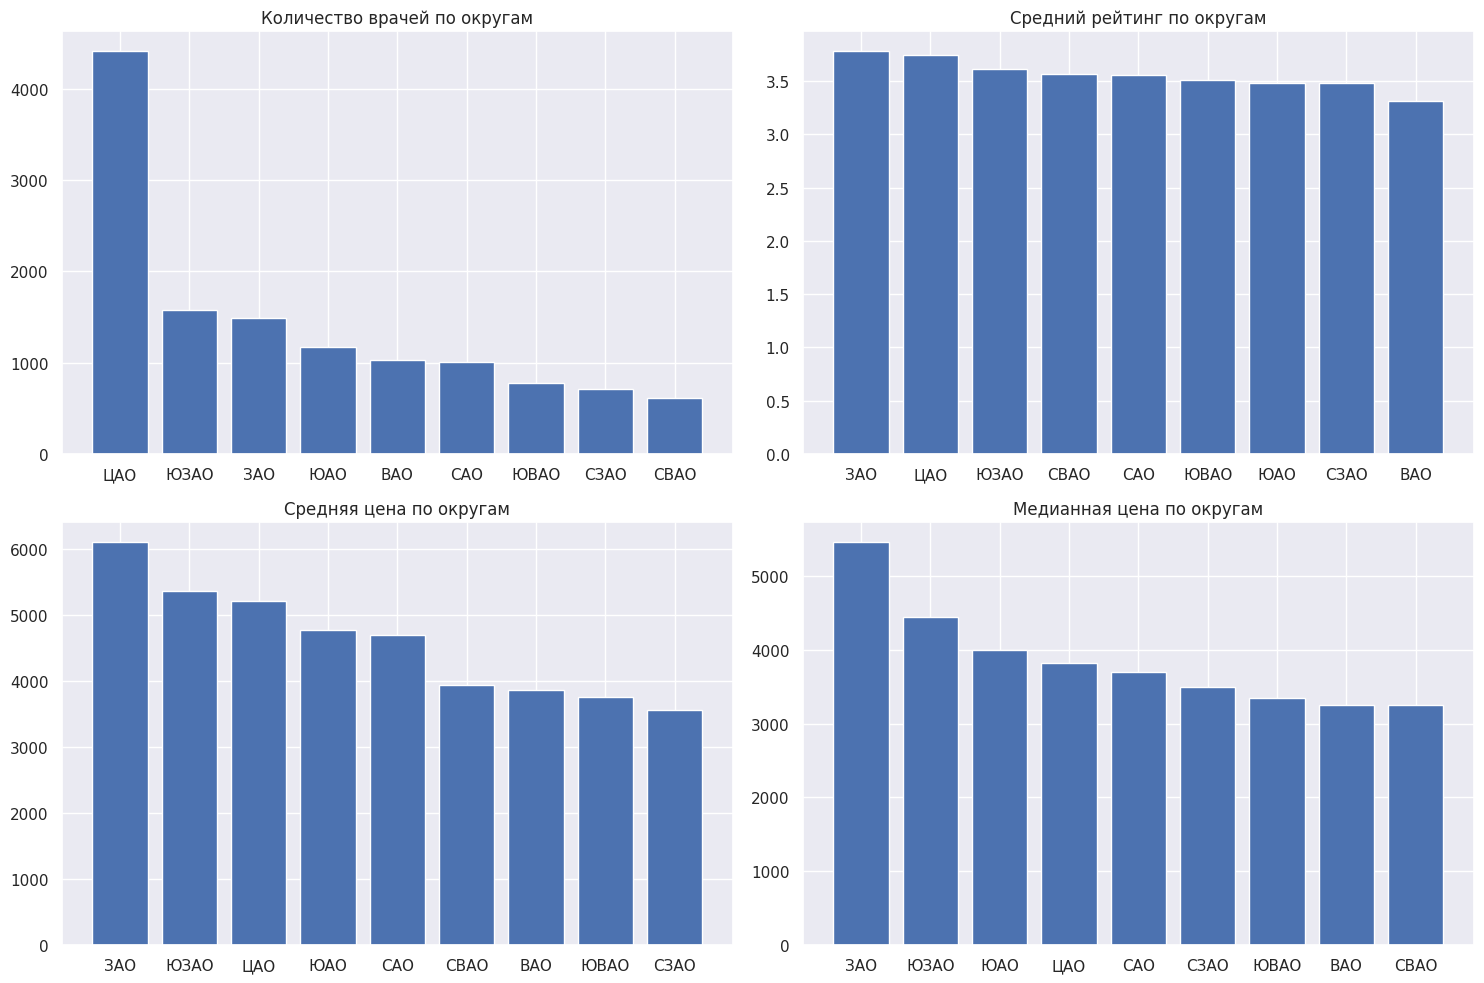

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

area_counts = data_moskow_okr['area'].value_counts()
axes[0,0].bar(area_counts.index, area_counts.values)
axes[0,0].set_title('Количество врачей по округам')
axes[0,0].tick_params(axis='x')

area_rating = data_moskow_okr.groupby('area')['rating'].mean().sort_values(ascending=False)
axes[0,1].bar(area_rating.index, area_rating.values)
axes[0,1].set_title('Средний рейтинг по округам')
axes[0,1].tick_params(axis='x')

area_price = data_moskow_okr.groupby('area')['price_avg'].mean().sort_values(ascending=False)
axes[1,0].bar(area_price.index, area_price.values)
axes[1,0].set_title('Средняя цена по округам')
axes[1,0].tick_params(axis='x')

area_med_price = data_moskow_okr.groupby('area')['price_avg'].median().sort_values(ascending=False)
axes[1,1].bar(area_med_price.index, area_med_price.values)
axes[1,1].set_title('Медианная цена по округам')
axes[1,1].tick_params(axis='x')

plt.tight_layout()
plt.show()

Заметим, что ЗАО выделяется по цене и рейтингу, вероятно, в этом округе более престижная медицина

Также в ЦАО сконцентрировано наибольшее количество врачей, и является одним из самых высоких среди средних рейтингов и цен

ВАО, СВАО, ЮВАО, СЗАО - наименьшие цены и количество докторов - возможно меньший спрос

### Карта рейтингов по округам

С цветовыми точками, в зависимости от рейтинга

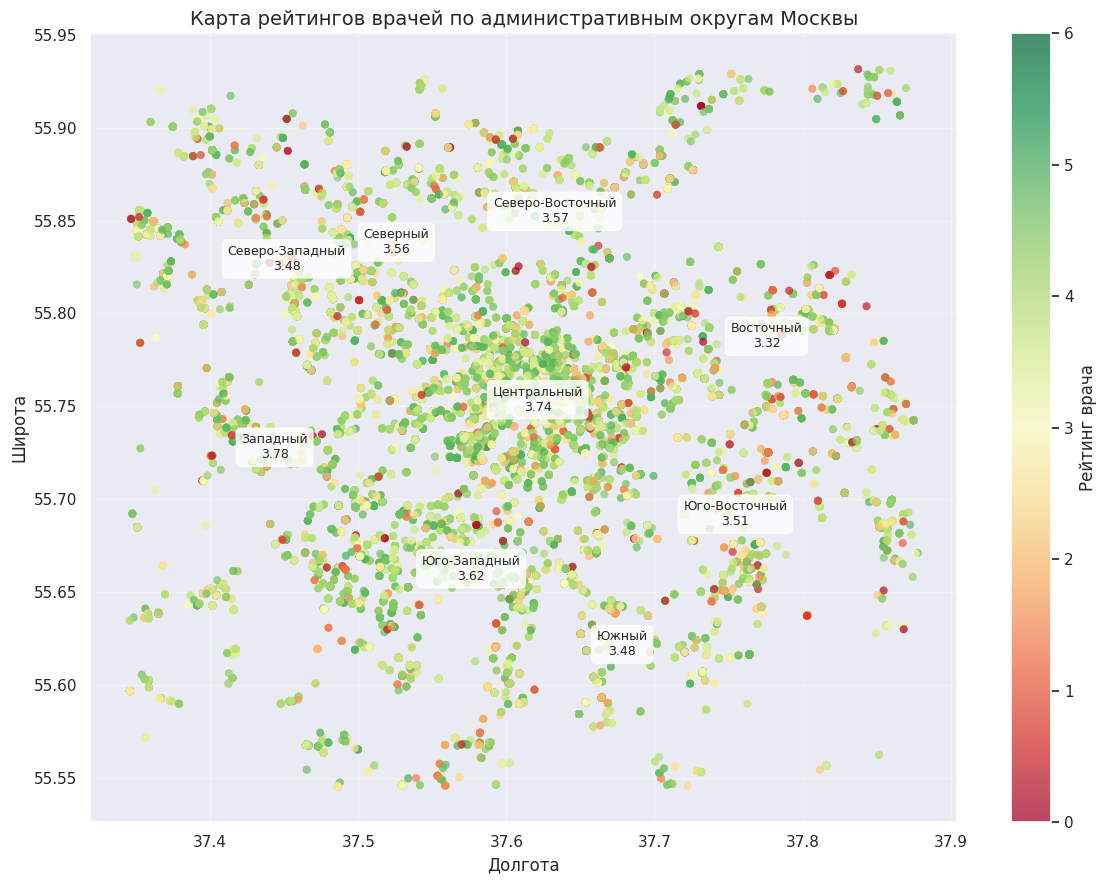

In [ ]:
area_avg_ratings = data_moskow.groupby('area')['rating'].mean()

plt.figure(figsize=(12, 9))
scatter = plt.scatter(data_moskow['longitude'], data_moskow['latitude'],
                     c=data_moskow['rating'], cmap='RdYlGn', s=30, alpha=0.7, linewidth=0.3,vmax = 6)

cbar = plt.colorbar(scatter)
cbar.set_label('Рейтинг врача', fontsize=12)

areas = {
    'Центральный': (37.621184, 55.753600),
    'Северный': (37.525774, 55.838390),
    'Северо-Восточный': (37.632565, 55.854875),
    'Восточный': (37.775631, 55.787715),
    'Юго-Восточный': (37.754592, 55.692019),
    'Южный': (37.678065, 55.622014),
    'Юго-Западный': (37.576187, 55.662735),
    'Западный': (37.443533, 55.728003),
    'Северо-Западный': (37.451555, 55.829370),
    'Новомосковский': (37.371452,55.594351),
    'Троицкий': (37.146999,55.355802),
    'Зеленоградский': (37.194250,55.987583)
}

for area, (lon, lat) in areas.items():
    full_area_name = area + ' административный округ'
    if full_area_name in area_avg_ratings.index:
        avg_rating = area_avg_ratings[full_area_name]
        plt.annotate(f"{area}\n{avg_rating:.2f}", (lon, lat), fontsize=9, ha='center', va='center',
                    bbox=dict(boxstyle="round,pad=0.4", facecolor='white', alpha=0.8))

plt.xlabel('Долгота', fontsize=12)
plt.ylabel('Широта', fontsize=12)
plt.title('Карта рейтингов врачей по административным округам Москвы', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('card_2.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

Самые низкие показатели имеет Восточный район, а высокие - Западный и Центральный

In [ ]:
data_moskow.groupby('area')['rating'].mean().sort_values()

,rating
area,
Восточный административный округ,3.315471
Северо-Западный административный округ,3.480676
Южный административный округ,3.483171
Юго-Восточный административный округ,3.509646
Северный административный округ,3.559655
Северо-Восточный административный округ,3.571839
Юго-Западный административный округ,3.618725
Центральный административный округ,3.742798
Западный административный округ,3.780011


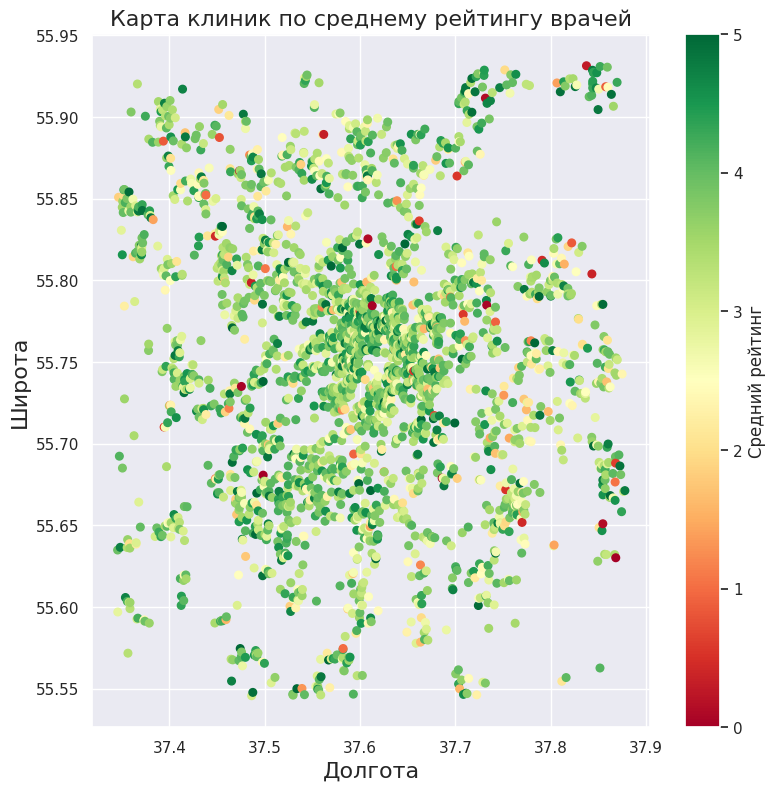

In [ ]:
plt.figure(figsize=(9, 9))

# Группируем по координатам и считаем средний рейтинг
grouped_data = data_moskow.groupby(['longitude', 'latitude'])['rating'].mean().reset_index()

scatter = plt.scatter(grouped_data['longitude'], grouped_data['latitude'],
                     c=grouped_data['rating'], cmap='RdYlGn', alpha=1, s=30, vmax = 5)

plt.xlabel('Долгота', fontsize=16)
plt.ylabel('Широта', fontsize=16)
plt.title('Карта клиник по среднему рейтингу врачей', fontsize=16)
plt.colorbar(scatter, label='Средний рейтинг')

plt.show()

Не очень репрезентативно, конкретная оценка рейтинга не сильно зависит от района, присутствуют, как высокие так и низкие, сильной цветовой концентрации нет, можно выделить только, что на Юго-Западе меньше низких оценок

Построим тепловыую карту, объединив близлежащие области

/tmp/ipython-input-956448298.py:9: FutureWarning:

The provided callable <function mean at 0x7bfcf414f880> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



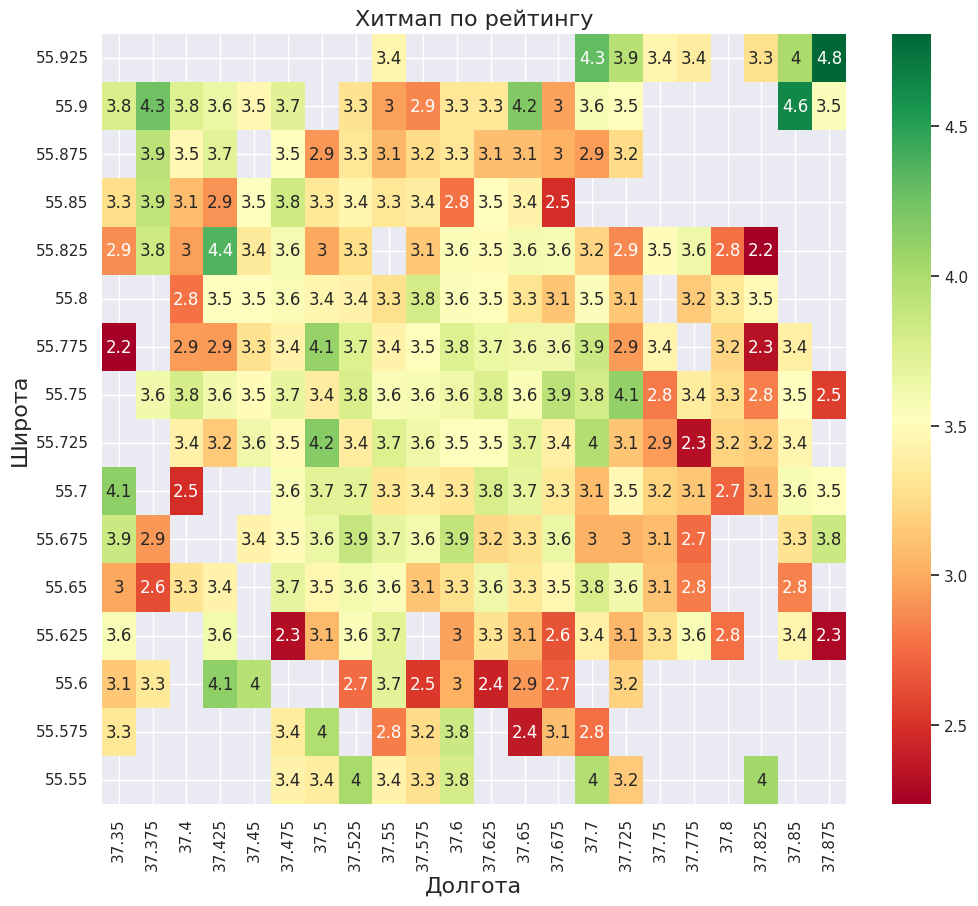

In [ ]:
plt.figure(figsize=(12,10))

cut_data = data_moskow.copy()
# Округляем координаты для группировки в ячейки сетки
# Умножаем на 4, округляем, делим на 4 - получаем сетку с шагом 0.25
cut_data['latitude'] = np.round(cut_data['latitude']*4, decimals=1)*0.25
cut_data['longitude'] = np.round(cut_data['longitude']*4, decimals=1)*0.25

table = pd.pivot_table(cut_data, values='rating', index=['latitude'],columns=['longitude'], aggfunc=np.mean)
table = table.sort_index(ascending=False)
table_count = pd.pivot_table(cut_data, values='rating', index=['latitude'], columns=['longitude'], aggfunc=np.size)
table_count = table_count.sort_index(ascending=False)
sns.heatmap(table, mask = table_count<4, cmap='RdYlGn', annot=True)

plt.xlabel('Долгота', fontsize=16)
plt.ylabel('Широта', fontsize=16)
plt.title('Хитмап по рейтингу', fontsize=16)

plt.show()

При небольшом объединении заметно ухудшение оценок на границах мкада, а также на Востоке, Юго-Востоке

### Карта Рейтинг с отзывов

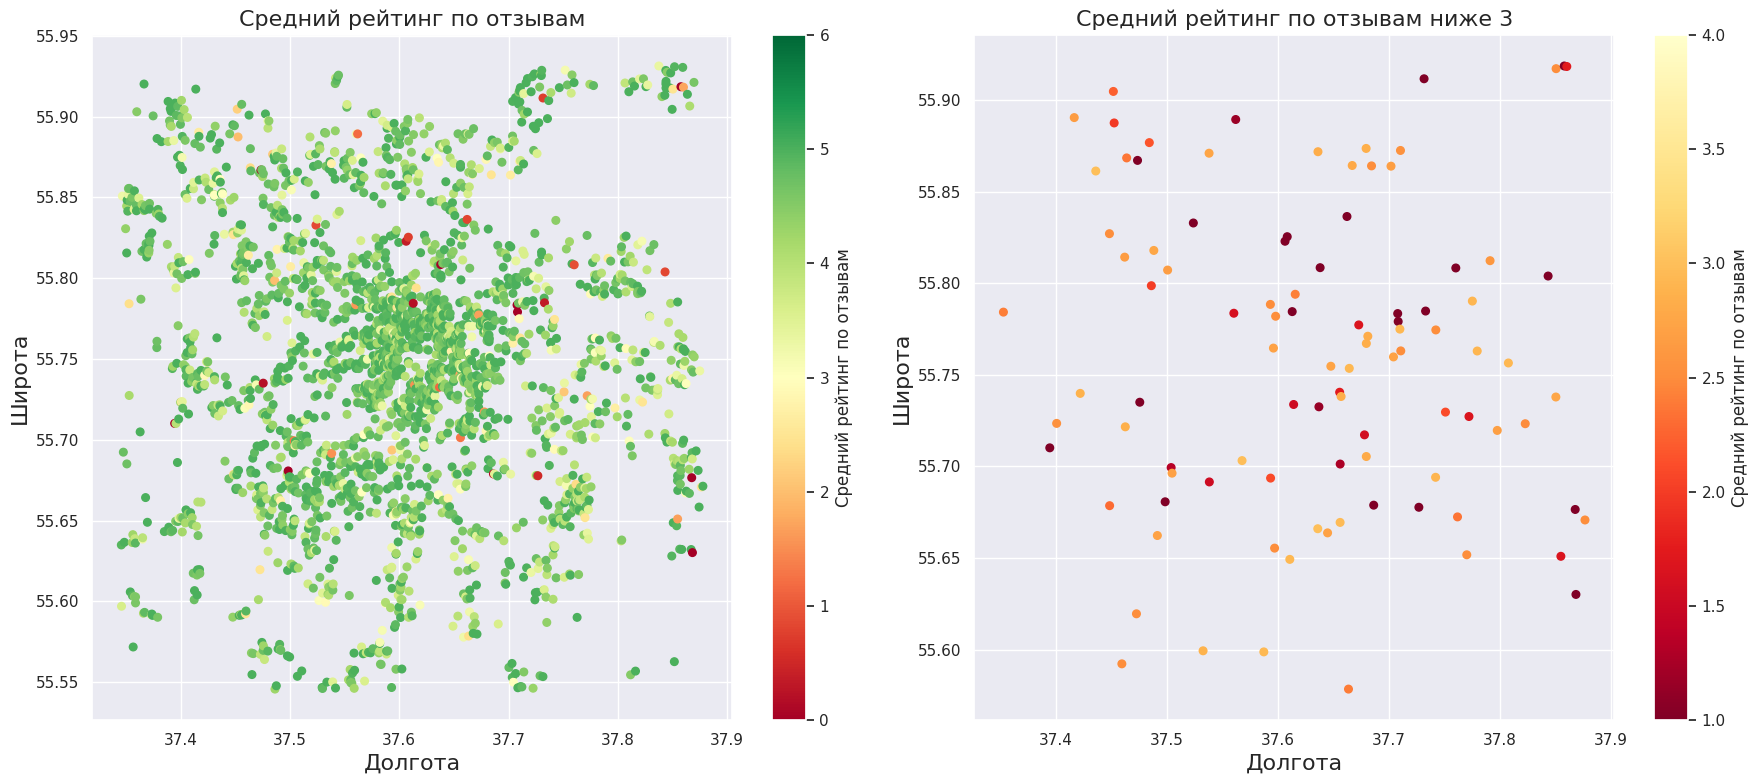

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Группируем по координатам и считаем средний рейтинг
grouped_data_1 = data_moskow.groupby(['longitude', 'latitude'])['review_rating'].mean().reset_index()

scatter0 = axes[0].scatter(grouped_data_1['longitude'], grouped_data_1['latitude'],
                     c=grouped_data_1['review_rating'], cmap='RdYlGn', alpha=1, s=30, vmax=6)
axes[0].set_xlabel('Долгота', fontsize=16)
axes[0].set_ylabel('Широта', fontsize=16)
axes[0].set_title('Средний рейтинг по отзывам', fontsize=16)
plt.colorbar(scatter0, ax=axes[0], label='Средний рейтинг по отзывам')

low_ratings = grouped_data_1[grouped_data_1['review_rating'] < 3]
scatter1 = axes[1].scatter(low_ratings['longitude'], low_ratings['latitude'],
                     c=low_ratings['review_rating'], cmap='YlOrRd_r', alpha=1, s=30, vmin=1, vmax=4)
axes[1].set_xlabel('Долгота', fontsize=16)
axes[1].set_ylabel('Широта', fontsize=16)
axes[1].set_title('Средний рейтинг по отзывам ниже 3', fontsize=16)
plt.colorbar(scatter1, ax=axes[1], label='Средний рейтинг по отзывам')

plt.tight_layout()
plt.savefig('card_3.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

среднюю оценку из отзывов все округа имеют высокие показатели >= 4.39, однако заметно достаточное кол-во отрицательных оценок

Рейтинг также не сильно зависит от района, можно выделить только, что на Юге почти отсутствую низкие оценки

### Карта по цене

Рассмотрим цену

In [ ]:
Q1 = data_moskow['price_avg'].quantile(0.25)
Q3 = data_moskow['price_avg'].quantile(0.75)
IQR = Q3 - Q1
lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR
print(lower_whisker,upper_whisker)

-1000.0 9400.0


In [ ]:
data_moskow['price_avg'].describe()

,price_avg
count,14578.000000
mean,4854.204555
std,3943.879448
min,500.000000
25%,2900.000000
50%,3680.000000
75%,5500.000000
max,150000.000000


уберем значения > Q3+3IQR на данном графике

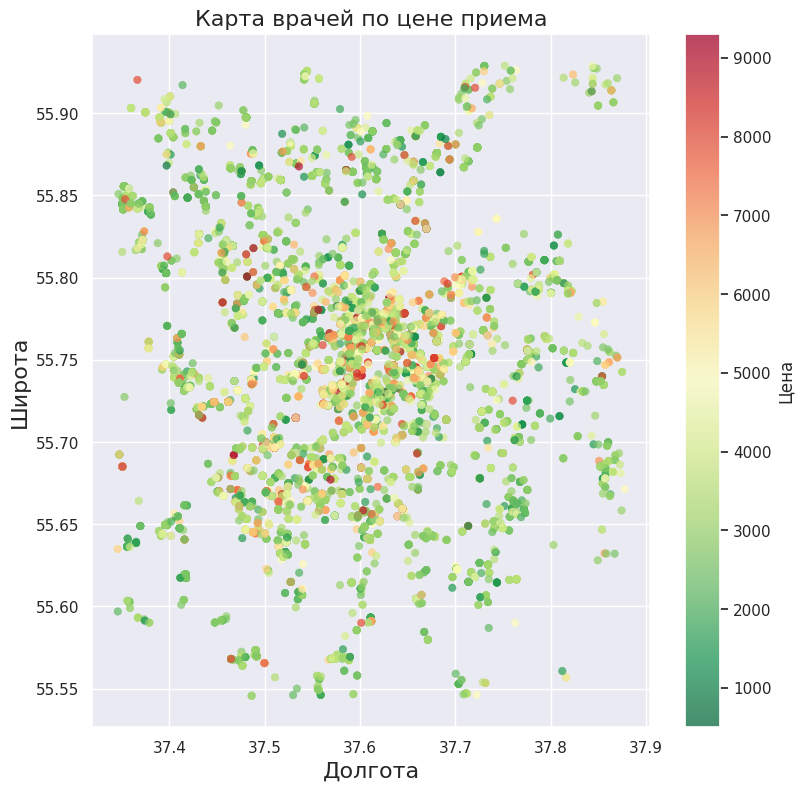

In [ ]:
plt.figure(figsize=(9, 9))

scatter = plt.scatter(data_moskow[data_moskow['price_avg'] < upper_whisker]['longitude'], data_moskow[data_moskow['price_avg'] < upper_whisker]['latitude'],
                     c=data_moskow[data_moskow['price_avg'] < upper_whisker]['price_avg'], cmap='RdYlGn_r',
                     alpha=0.7, s=30, linewidth=0.3)

plt.xlabel('Долгота', fontsize=16)
plt.ylabel('Широта', fontsize=16)
plt.title('Карта врачей по цене приема', fontsize=16)
plt.colorbar(scatter, label='Цена')
plt.show()

по графику замечаем, что на юге-востоке и периферии цены ниже, а в центре и северо-западе цены выше среднего и медианы

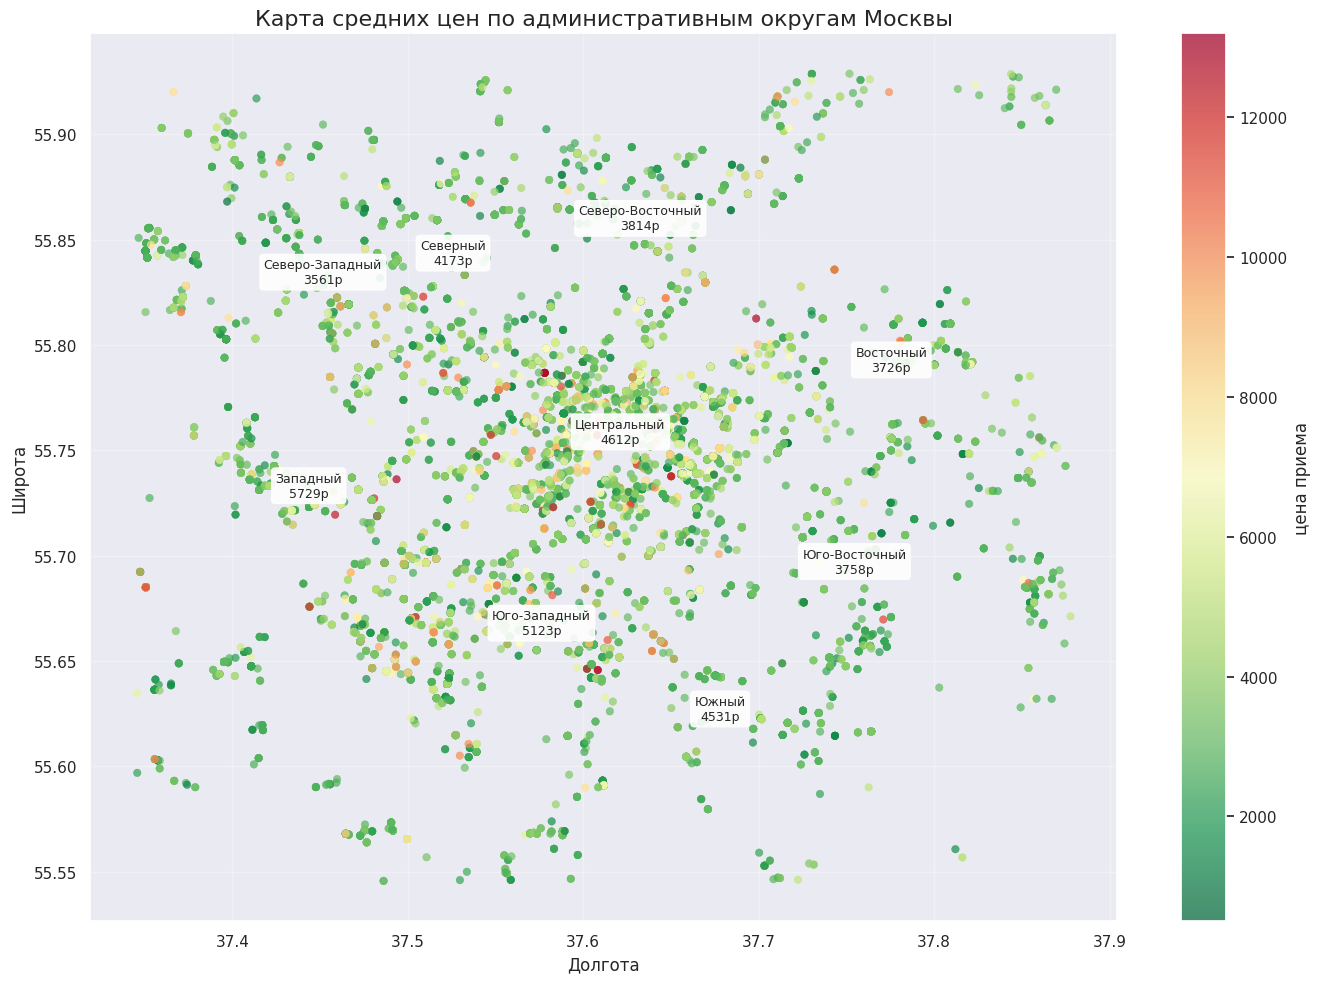

In [ ]:
plt.figure(figsize=(14, 10))

scatter = plt.scatter(data_moskow[data_moskow['price_avg'] < Q3+3*IQR]['longitude'], data_moskow[data_moskow['price_avg'] < Q3+3*IQR]['latitude'],
                     c=data_moskow[data_moskow['price_avg'] < Q3+3*IQR]['price_avg'], cmap='RdYlGn_r', s=30, alpha=0.7, linewidth=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label('цена приема', fontsize=12)

areas = {
    'Центральный': (37.621184, 55.753600),
    'Северный': (37.525774, 55.838390),
    'Северо-Восточный': (37.632565, 55.854875),
    'Восточный': (37.775631, 55.787715),
    'Юго-Восточный': (37.754592, 55.692019),
    'Южный': (37.678065, 55.622014),
    'Юго-Западный': (37.576187, 55.662735),
    'Западный': (37.443533, 55.728003),
    'Северо-Западный': (37.451555, 55.829370),
    'Новомосковский': (37.371452,55.594351),
    'Троицкий': (37.146999,55.355802),
    'Зеленоградский': (37.194250,55.987583)
}

area_avg_prices = data_moskow[data_moskow['price_avg'] < Q3+3*IQR].groupby('area')['price_avg'].mean()
for area, (lon, lat) in areas.items():
    full_area_name = area + ' административный округ'
    if full_area_name in area_avg_prices.index:
        avg_price = area_avg_prices[full_area_name]
        plt.annotate(f"{area}\n{avg_price:.0f}р", (lon, lat), fontsize=9, ha='center',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9))

plt.xlabel('Долгота', fontsize=12)
plt.ylabel('Широта', fontsize=12)
plt.title('Карта средних цен по административным округам Москвы', fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('card_4.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipython-input-2860895889.py:8: FutureWarning:

The provided callable <function mean at 0x7bfcf414f880> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



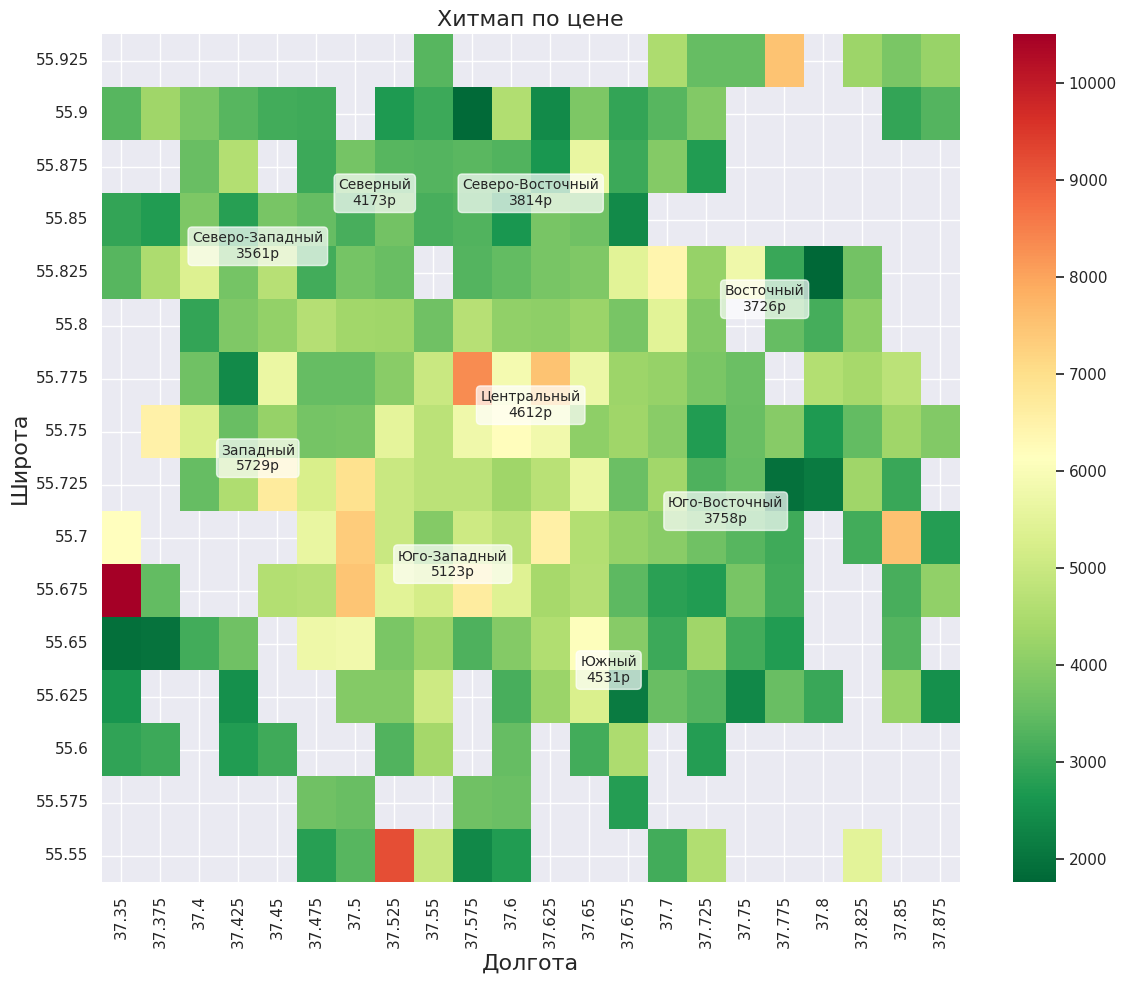

In [ ]:
plt.figure(figsize=(12,10))

cut_data = data_moskow.copy()
# Округляем координаты для группировки в ячейки сетки
cut_data['latitude'] = np.round(cut_data['latitude']*4, decimals=1)*0.25
cut_data['longitude'] = np.round(cut_data['longitude']*4, decimals=1)*0.25

table = pd.pivot_table(cut_data, values='price_avg', index=['latitude'],columns=['longitude'], aggfunc=np.mean)
table = table.sort_index(ascending=False)
table_count = pd.pivot_table(cut_data, values='price_avg', index=['latitude'], columns=['longitude'], aggfunc=np.size)
table_count = table_count.sort_index(ascending=False)

ax = sns.heatmap(table, mask = table_count<4, cmap='RdYlGn_r', vmax = 10500)

areas = {
    'Центральный': (37.621184, 55.753600),
    'Северный': (37.525774, 55.838390),
    'Северо-Восточный': (37.632565, 55.854875),
    'Восточный': (37.775631, 55.787715),
    'Юго-Восточный': (37.754592, 55.692019),
    'Южный': (37.678065, 55.622014),
    'Юго-Западный': (37.576187, 55.662735),
    'Западный': (37.443533, 55.728003),
    'Северо-Западный': (37.451555, 55.829370),
    'Новомосковский': (37.371452,55.594351),
    'Троицкий': (37.146999,55.355802),
    'Зеленоградский': (37.194250,55.987583)
}

area_avg_prices = data_moskow[data_moskow['price_avg'] < Q3+3*IQR].groupby('area')['price_avg'].mean()
for area, (lon, lat) in areas.items():
    full_area_name = area + ' административный округ'
    if full_area_name in area_avg_prices.index:
        avg_price = area_avg_prices[full_area_name]

        # Преобразуем географические координаты в координаты ячеек хитмапа, тк там строится по индексам
        lat_idx = np.round(lat*4, decimals=1)*0.25
        lon_idx = np.round(lon*4, decimals=1)*0.25

        x_pos = list(table.columns).index(lon_idx)
        y_pos = list(table.index).index(lat_idx)

        ax.annotate(f"{area}\n{avg_price:.0f}р",
                    (x_pos, y_pos),
                    fontsize=10,
                    ha='center',
                    va='center',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

plt.xlabel('Долгота', fontsize=16)
plt.ylabel('Широта', fontsize=16)
plt.title('Хитмап по цене', fontsize=16)

plt.tight_layout()
plt.show()

Стоит отметить, что самая высокая цена не в центральном районе, а в Западном округе, далее в Юго-Западном. Минимальная средняя цена в Северно-Западном.

In [ ]:
area_avg_prices = data_moskow[data_moskow['price_avg'] < Q3+3*IQR].groupby('area')[['price_avg', 'rating']].mean().sort_values(by = 'price_avg', ascending = False)

In [ ]:
area_avg_prices

,price_avg,rating
area,,
Западный административный округ,5728.599692,4.042668
Юго-Западный административный округ,5122.749658,4.046799
Центральный административный округ,4612.154678,4.018943
Южный административный округ,4531.497619,4.081387
Северный административный округ,4173.178917,3.782711
Северо-Восточный административный округ,3814.442667,3.933305
Юго-Восточный административный округ,3757.886792,3.911167
Восточный административный округ,3725.872917,3.928251
Северо-Западный административный округ,3560.861635,3.923305


посмотрим на выбросы по ценам

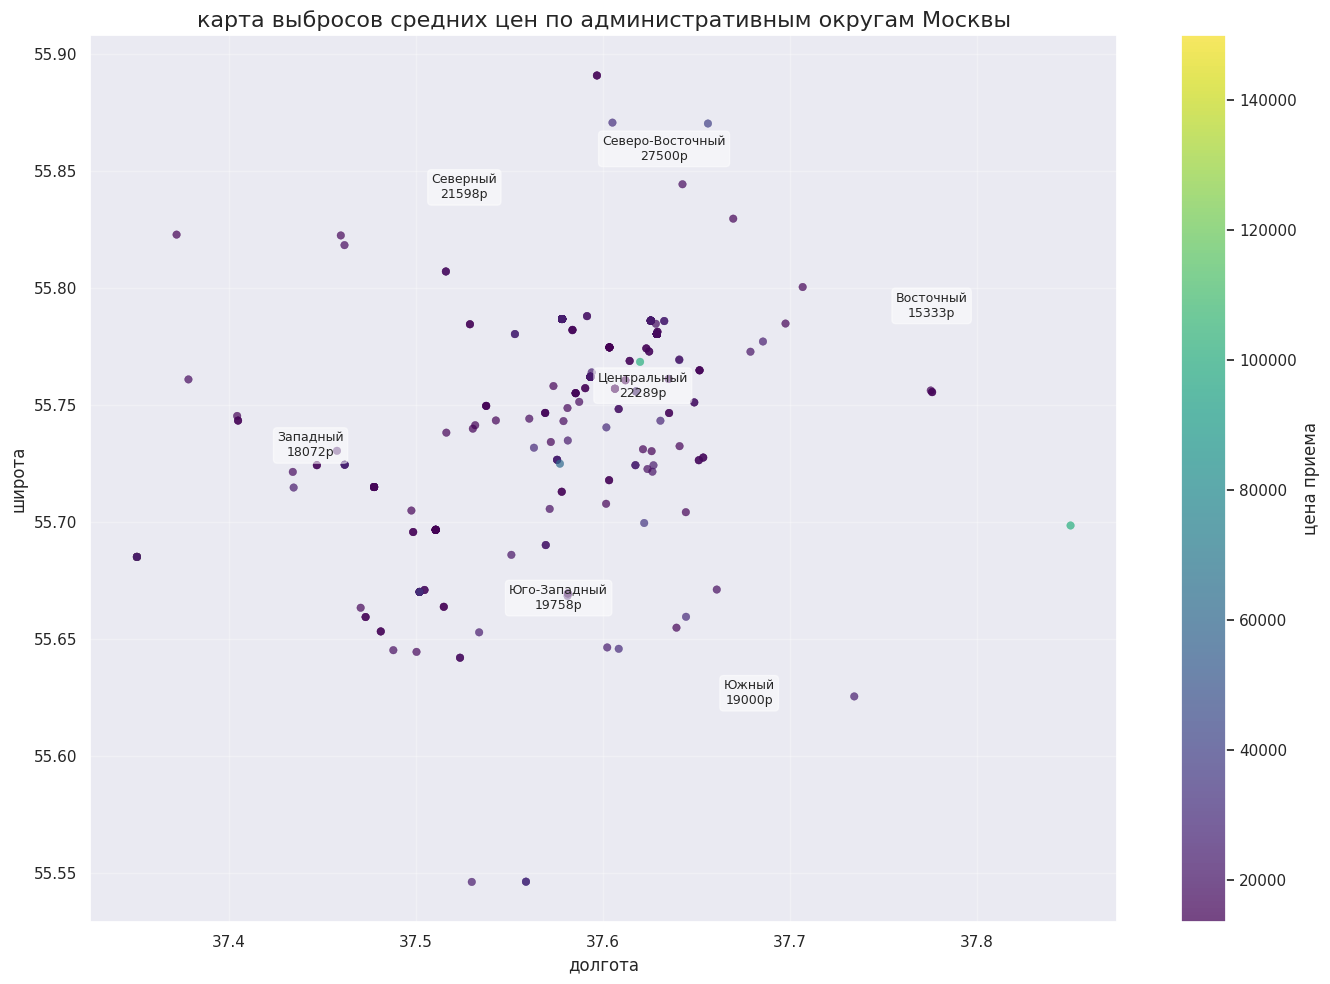

In [ ]:
plt.figure(figsize=(14, 10))

scatter = plt.scatter(data_moskow[data_moskow['price_avg'] >= Q3+3*IQR]['longitude'], data_moskow[data_moskow['price_avg'] >= Q3+3*IQR]['latitude'],
                     c=data_moskow[data_moskow['price_avg'] >= Q3+3*IQR]['price_avg'], cmap='viridis', s=30, alpha=0.7, linewidth=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label('цена приема', fontsize=12)

areas = {
    'Центральный': (37.621184, 55.753600),
    'Северный': (37.525774, 55.838390),
    'Северо-Восточный': (37.632565, 55.854875),
    'Восточный': (37.775631, 55.787715),
    'Юго-Восточный': (37.754592, 55.692019),
    'Южный': (37.678065, 55.622014),
    'Юго-Западный': (37.576187, 55.662735),
    'Западный': (37.443533, 55.728003),
    'Северо-Западный': (37.451555, 55.829370),
    'Новомосковский': (37.371452,55.594351),
    'Троицкий': (37.146999,55.355802),
    'Зеленоградский': (37.194250,55.987583)
}

area_avg_prices = data_moskow[data_moskow['price_avg'] >= Q3+3*IQR].groupby('area')['price_avg'].mean()
for area, (lon, lat) in areas.items():
    full_area_name = area + ' административный округ'
    if full_area_name in area_avg_prices.index:
        avg_price = area_avg_prices[full_area_name]
        plt.annotate(f"{area}\n{avg_price:.0f}р", (lon, lat), fontsize=9, ha='center',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.5))

plt.xlabel('долгота', fontsize=12)
plt.ylabel('широта', fontsize=12)
plt.title('карта выбросов средних цен по административным округам Москвы', fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Выбросы сконцентрированы в Центральном, Западном и Юго-Западном районе

In [ ]:
area_avg_prices = data_moskow[data_moskow['price_avg'] >= Q3+3*IQR].groupby('area')['price_avg'].mean()

In [ ]:
data_moskow['price_avg'].describe()

,price_avg
count,14578.000000
mean,4854.204555
std,3943.879448
min,500.000000
25%,2900.000000
50%,3680.000000
75%,5500.000000
max,150000.000000


## Карта по пациентам

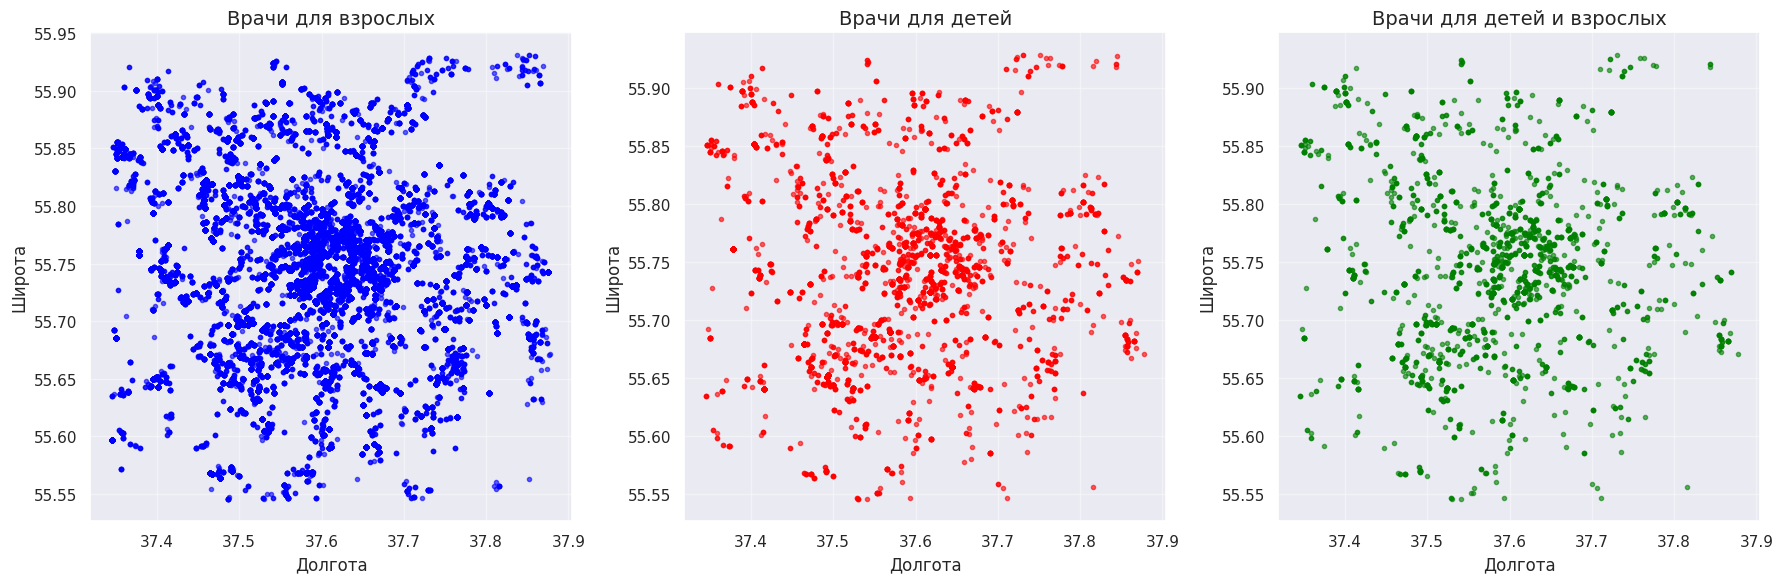

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

kids_clinics = data_moskow[data_moskow['is_kids'] == True]
adults_clinics = data_moskow[data_moskow['is_adults'] == True]
both_clinics = data_moskow[(data_moskow['is_kids'] == True) & (data_moskow['is_adults'] == True)]

axes[0].plot(adults_clinics['longitude'], adults_clinics['latitude'], 'o', alpha=0.6, color='blue', markersize=3)
axes[0].set_title('Врачи для взрослых', fontsize=14)
axes[0].set_xlabel('Долгота')
axes[0].set_ylabel('Широта')
axes[0].grid(alpha=0.4)

axes[1].plot(kids_clinics['longitude'], kids_clinics['latitude'], 'o', alpha=0.6, color='red', markersize=3)
axes[1].set_title('Врачи для детей', fontsize=14)
axes[1].set_xlabel('Долгота')
axes[1].set_ylabel('Широта')
axes[1].grid(alpha=0.4)

axes[2].plot(both_clinics['longitude'], both_clinics['latitude'], 'o', alpha=0.6, color='green', markersize=3)
axes[2].set_title('Врачи для детей и взрослых', fontsize=14)
axes[2].set_xlabel('Долгота')
axes[2].set_ylabel('Широта')
axes[2].grid(alpha=0.4)

plt.tight_layout()
plt.show()

Нельзя выделить закономерности или сильную концентрацию с определенных районах,  концентрация совпадает с общим количеством докторов

## Районы

Заменим все значения, содержащие "микрорайон", так слишком узкая выборка

In [ ]:
data_moskow['district'] = data_moskow['district'].replace({'Ошибка': None})
data_moskow.loc[data_moskow['district'].str.contains('микрорайон', case=False, na=False), 'district'] = None

Посмотрим по районам максимальные по признакам: количество врачей, рейтинг, цена

In [ ]:
bubble_data = data_moskow.groupby('district').agg({
    'doctor_name': 'count',
    'rating': 'mean',
    'price_avg': 'median'
}).reset_index()

bubble_data_doctor_name = bubble_data.sort_values('doctor_name', ascending = False)
bubble_data_doctor_name.head(15)

,district,doctor_name,rating,price_avg
99,район Хамовники,802,3.662399,3600.0
15,Мещанский район,763,3.593351,4100.0
25,Тверской район,618,4.125557,3900.0
24,Таганский район,534,3.801410,3680.0
21,Пресненский район,478,3.547638,3675.0
82,район Раменки,443,3.807307,6000.0
4,Басманный район,407,3.720652,3750.0
68,район Нагатино-Садовники,403,3.322293,3995.0
19,Обручевский район,362,3.625570,6500.0
33,район Беговой,354,3.356234,9850.0


Максимальные по количеству врачей:

район Хамовники

Мещанский район

Тверской район

Таганский район

In [ ]:
bubble_data_rating = bubble_data.sort_values('rating', ascending = False)
bubble_data_rating.head(15)

,district,doctor_name,rating,price_avg
37,район Братеево,2,4.922522,1855.0
76,район Очаково-Матвеевское,11,4.500955,5950.0
39,район Восточное Дегунино,2,4.498458,2675.0
48,район Ивановское,1,4.461576,3250.0
45,район Западное Дегунино,18,4.368253,3000.0
65,район Метрогородок,3,4.281007,2750.0
20,Останкинский район,21,4.262403,3000.0
57,район Куркино,44,4.259453,3500.0
47,район Зябликово,10,4.256968,3200.0
40,район Восточное Измайлово,21,4.249061,3500.0


Максимальные по рейтингу:

район Братеево

район Очаково-Матвеевско

район Восточное Дегунино

район Ивановское

In [ ]:
bubble_data_price_final = bubble_data.sort_values('price_avg', ascending = False)
bubble_data_price_final.head(15)

,district,doctor_name,rating,price_avg
33,район Беговой,354,3.356234,9850.0
81,район Проспект Вернадского,247,3.898265,8190.0
19,Обручевский район,362,3.625570,6500.0
106,район Черёмушки,237,3.863433,6400.0
82,район Раменки,443,3.807307,6000.0
76,район Очаково-Матвеевское,11,4.500955,5950.0
96,район Тёплый Стан,69,3.800125,5950.0
98,район Филёвский Парк,51,3.610712,5340.0
10,Даниловский район,168,3.878336,5250.0
44,район Замоскворечье,259,3.629961,5060.0


Максимальные по цене:

район Беговой

район Проспект Вернадского

Обручевский район

район Черёмушки

### Bubble diagram

Совместим три переменные и посмотрим на графике

In [ ]:
bubble_data_mean = data_moskow.groupby('district').agg({
    'doctor_name': 'count',
    'rating': 'mean',
    'price_avg': 'mean'
}).reset_index()

bubble_data_mean_doctor_name = bubble_data.sort_values('doctor_name', ascending = False)
bubble_data_mean_doctor_name.head(15)

,district,doctor_name,rating,price_avg
99,район Хамовники,802,3.662399,3600.0
15,Мещанский район,763,3.593351,4100.0
25,Тверской район,618,4.125557,3900.0
24,Таганский район,534,3.801410,3680.0
21,Пресненский район,478,3.547638,3675.0
82,район Раменки,443,3.807307,6000.0
4,Басманный район,407,3.720652,3750.0
68,район Нагатино-Садовники,403,3.322293,3995.0
19,Обручевский район,362,3.625570,6500.0
33,район Беговой,354,3.356234,9850.0


In [ ]:
import plotly.express as px

top_10_names = bubble_data.nlargest(10, 'doctor_name')['district'].tolist()
bubble_data['legend_group'] = bubble_data['district'].apply(
    lambda x: x if x in top_10_names else 'Другие районы'
)

fig = px.scatter(bubble_data,
                 x='rating',
                 y='price_avg',
                 size='doctor_name',
                 size_max=50,
                 color='legend_group',
                 color_discrete_sequence=px.colors.qualitative.Dark24,
                 hover_name='district',
                 hover_data={
                     'rating': ':.2f',
                     'price_avg': ':.0f',
                     'doctor_name': True
                 },
                 title='Сравнение медианной цены и рейтинга по району<br><sub>с учетом количества врачей в районе</sub>',
                 labels={
                     'rating': 'Средний рейтинг',
                     'price_avg': 'Медианная цена',
                     'doctor_name': 'Количество врачей',
                     'legend_group': 'Районы'
                 })

fig.update_layout(
    width=1350,
    height=890
)

fig.show()

In [ ]:
import plotly.express as px

top_10_names = bubble_data_mean.nlargest(10, 'doctor_name')['district'].tolist()
bubble_data_mean['legend_group'] = bubble_data_mean['district'].apply(
    lambda x: x if x in top_10_names else 'Другие районы'
)

fig = px.scatter(bubble_data_mean,
                 x='rating',
                 y='price_avg',
                 size='doctor_name',
                 size_max=50,
                 color='legend_group',
                 color_discrete_sequence=px.colors.qualitative.Dark24,
                 hover_name='district',
                 hover_data={
                     'rating': ':.2f',
                     'price_avg': ':.0f',
                     'doctor_name': True
                 },
                 title='Сравнение средней цены и рейтинга по району<br><sub>с учетом количества врачей в районе</sub>',
                 labels={
                     'rating': 'Средний рейтинг',
                     'price_avg': 'Средняя цена',
                     'doctor_name': 'Количество врачей',
                     'legend_group': 'Районы'
                 })

fig.update_layout(
    width=1350,
    height=890
)

fig.show()

# Вывод

1. Плотность расположения

На карте Москвы наблюдается высокая концентрация клиник в ЦАО и Юго-Западных районах, а также вдоль основных транспортных магистралей. Районы с такими же высокими показателями относятся к этим округам.

2. Стоимость

Наиболее высокая стоимость наблюдается в ЦАО, ЮЗАО и ЗАО, там же больше всего выбросов по цене. Районы с такими же высокими показателями относятся к этим округам.

ВАО, СВАО, ЮВАО, СЗАО - наименьшие цены. Районы в целом аналогично.

3. Рейтинги

В среднем самые низкие показатели имеет Восточный округ, а высокие - Западный и Центральный. Однако по отдельным районам возможны противоположные результаты.

Рейтинг по отзывам в среднем имеет относительно высокую оценку >= 4.39, распределен равномерно районам, однако в ЮЗАО заметно меньшее количество плохих оценок.

4. Зависимости от опыта, специальности, типу пациентов не обнаружено

# Проверка стат. гипотез

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import itertools
from itertools import combinations
import matplotlib.pyplot as plt
from scipy import stats

##ГИПОТЕЗА 1. Средний рейтинг отличается между округами

H0: рейтинги разных округов одинаковые

H1: хотя бы в одном округе рейтинг отличается от остальных

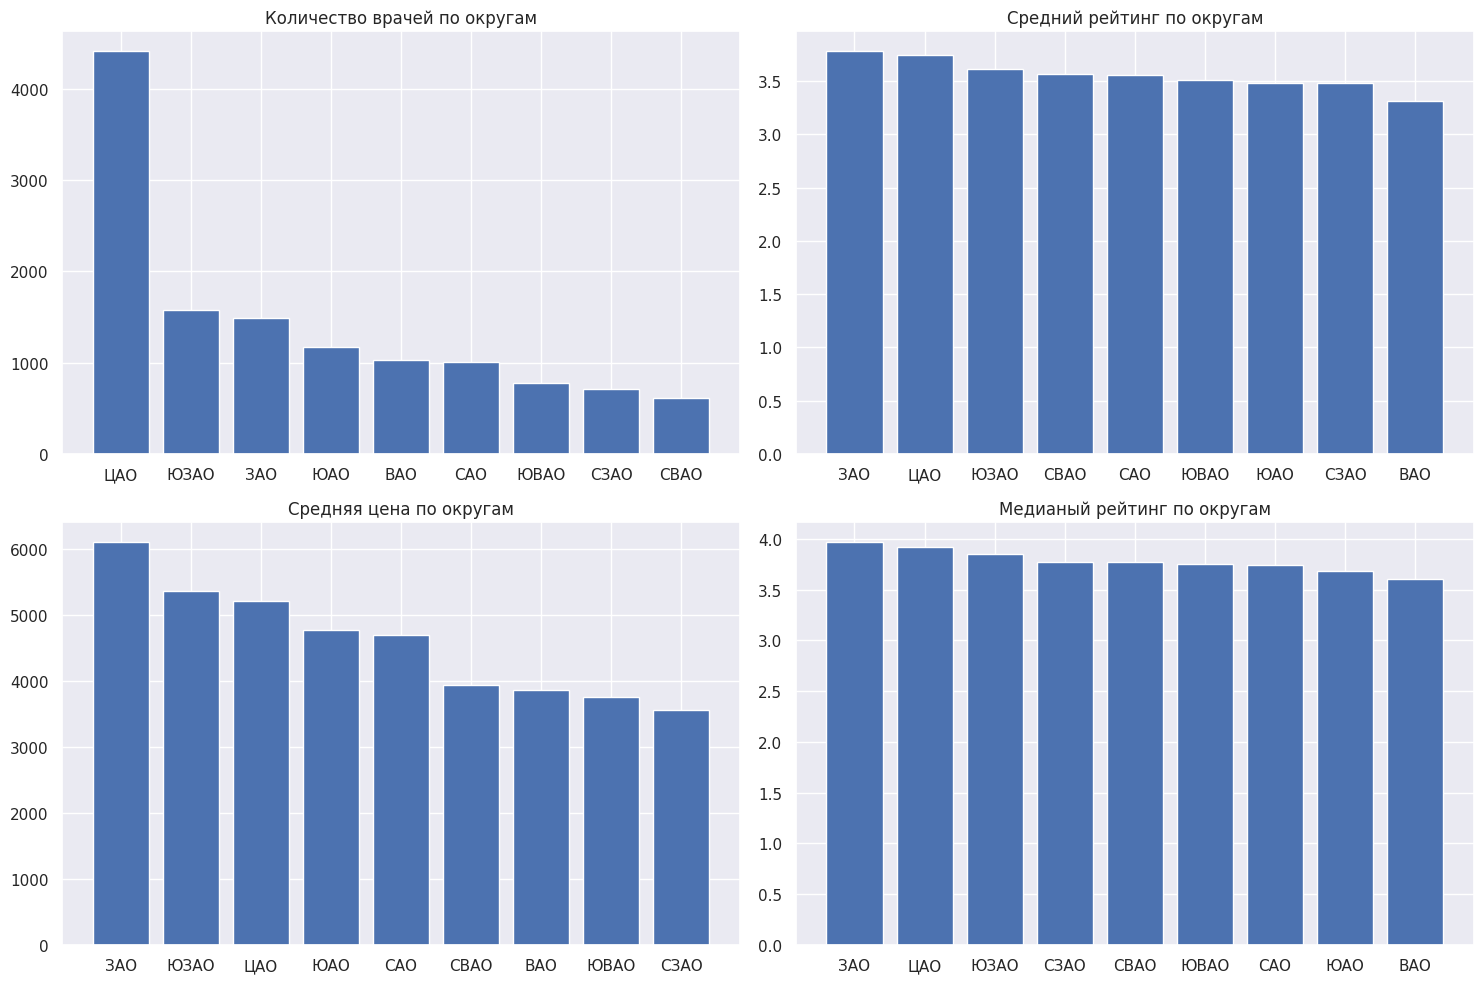

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

area_counts = data_moskow_okr['area'].value_counts()
axes[0,0].bar(area_counts.index, area_counts.values)
axes[0,0].set_title('Количество врачей по округам')
axes[0,0].tick_params(axis='x')

area_rating = data_moskow_okr.groupby('area')['rating'].mean().sort_values(ascending=False)
axes[0,1].bar(area_rating.index, area_rating.values)
axes[0,1].set_title('Средний рейтинг по округам')
axes[0,1].tick_params(axis='x')

area_price = data_moskow_okr.groupby('area')['price_avg'].mean().sort_values(ascending=False)
axes[1,0].bar(area_price.index, area_price.values)
axes[1,0].set_title('Средняя цена по округам')
axes[1,0].tick_params(axis='x')

area_med_price = data_moskow_okr.groupby('area')['rating'].median().sort_values(ascending=False)
axes[1,1].bar(area_med_price.index, area_med_price.values)
axes[1,1].set_title('Медианый рейтинг по округам')
axes[1,1].tick_params(axis='x')

plt.tight_layout()
plt.show()

источники тестов для проверки распределений:
1) АД - https://ru.wikipedia.org/wiki/%D0%9A%D1%80%D0%B8%D1%82%D0%B5%D1%80%D0%B8%D0%B9_%D0%90%D0%BD%D0%B4%D0%B5%D1%80%D1%81%D0%BE%D0%BD%D0%B0_%E2%80%94_%D0%94%D0%B0%D1%80%D0%BB%D0%B8%D0%BD%D0%B3%D0%B0
2) KS - https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test

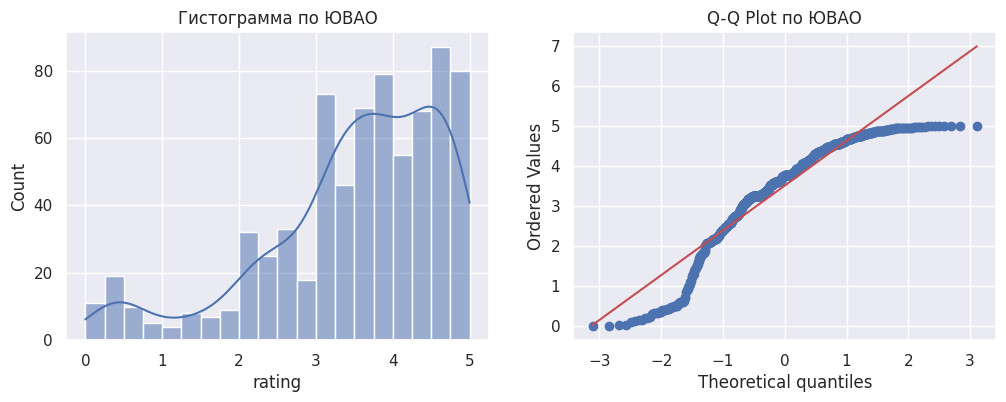

андерсон дарилнг тест: 18.116193805947205 [0.573 0.652 0.783 0.913 1.086] [15.  10.   5.   2.5  1. ]
K-S тест p-value: 3.956997703975584e-08


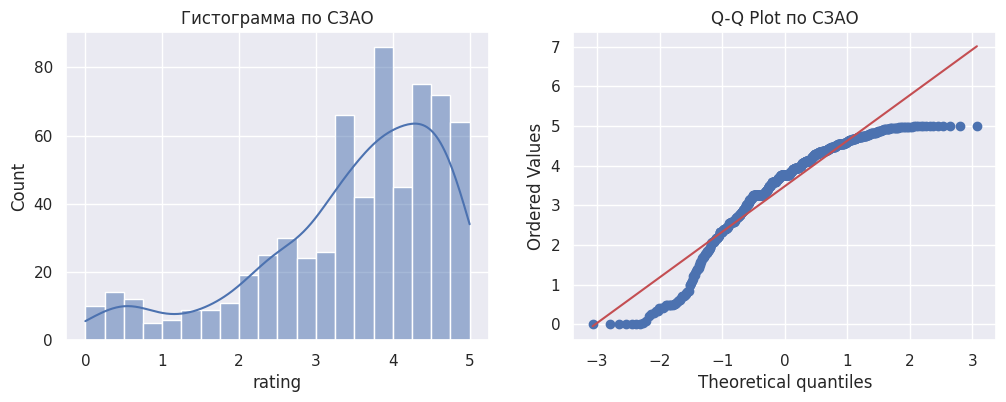

андерсон дарилнг тест: 17.270932775596748 [0.573 0.652 0.782 0.912 1.085] [15.  10.   5.   2.5  1. ]
K-S тест p-value: 1.9598680371121616e-08


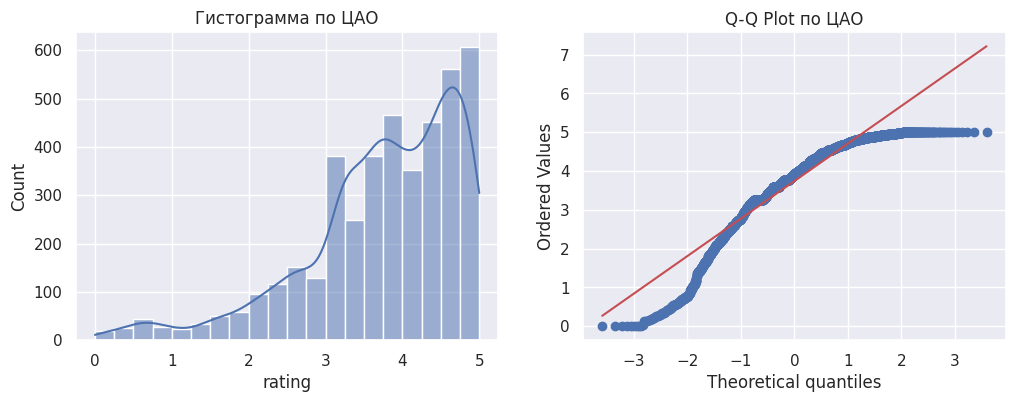

андерсон дарилнг тест: 94.8892295711048 [0.575 0.655 0.786 0.917 1.091] [15.  10.   5.   2.5  1. ]
K-S тест p-value: 2.045628435820848e-43


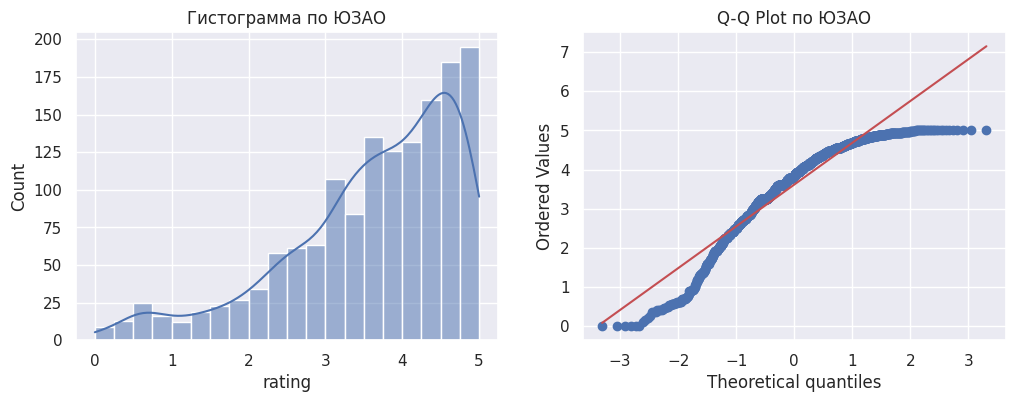

андерсон дарилнг тест: 36.17714684575935 [0.574 0.654 0.785 0.916 1.089] [15.  10.   5.   2.5  1. ]
K-S тест p-value: 1.2488021988271495e-15


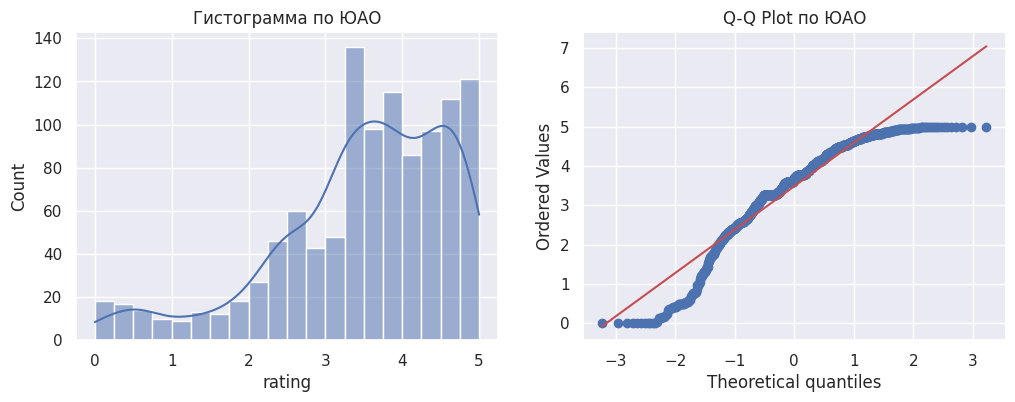

андерсон дарилнг тест: 21.641707991648218 [0.574 0.654 0.784 0.915 1.088] [15.  10.   5.   2.5  1. ]
K-S тест p-value: 3.8664827419555235e-13


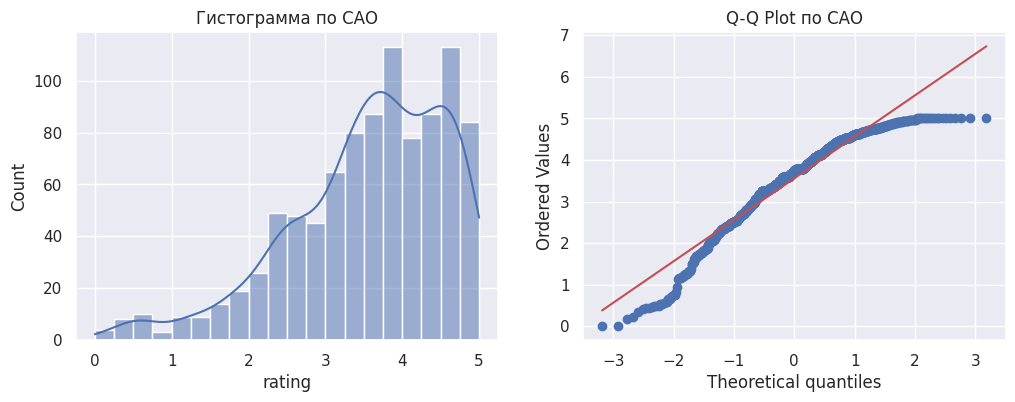

андерсон дарилнг тест: 13.319707064020122 [0.574 0.653 0.784 0.914 1.087] [15.  10.   5.   2.5  1. ]
K-S тест p-value: 1.110950090628124e-06


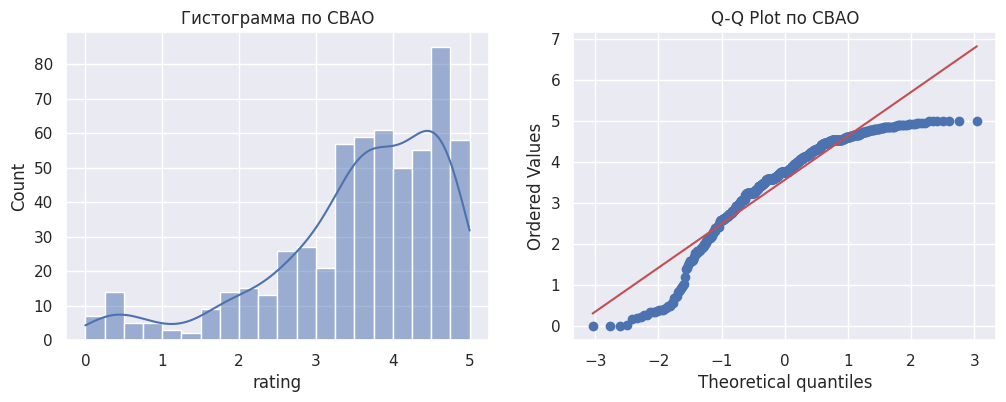

андерсон дарилнг тест: 16.356269576106683 [0.572 0.652 0.782 0.912 1.085] [15.  10.   5.   2.5  1. ]
K-S тест p-value: 1.320903542713705e-07


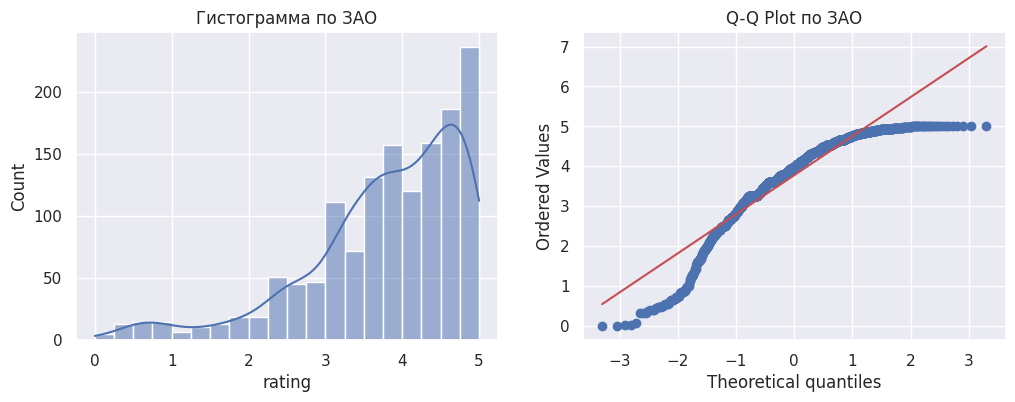

андерсон дарилнг тест: 37.69324574789084 [0.574 0.654 0.785 0.915 1.089] [15.  10.   5.   2.5  1. ]
K-S тест p-value: 3.957287361745977e-18


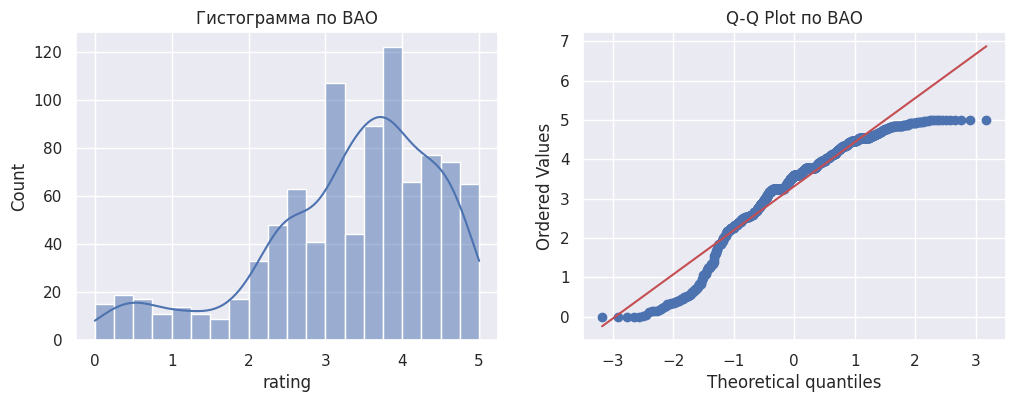

андерсон дарилнг тест: 17.55105132456572 [0.574 0.653 0.784 0.914 1.087] [15.  10.   5.   2.5  1. ]
K-S тест p-value: 3.3754566853882674e-11


In [ ]:
df = data_moskow_okr[['area', 'rating']].dropna()
areas = df["area"].dropna().unique()

for area in areas:
    data = df[df["area"] == area]["rating"].dropna()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(data, kde=True, ax=ax[0], bins=20)
    ax[0].set_title(f"Гистограмма по {area}")

    stats.probplot(data, dist="norm", plot=ax[1])
    ax[1].set_title(f"Q-Q Plot по {area}")

    plt.show()

    # андерсон дарилнг тест, проверяем нормальность
    ad_stat, crit_values, sig_levels = stats.anderson(data, dist='norm')
    print("андерсон дарилнг тест:", ad_stat, crit_values, sig_levels)

    #K-S тест
    mu, sigma = data.mean(), data.std()
    ks_stat, ks_p = stats.kstest(data, 'norm', args=(mu, sigma))
    print(f"K-S тест p-value: {ks_p}")

Распределения рейтингов не нормальны.

In [ ]:
groups = {area: df[df['area'] == area]['rating'].values.astype(float)
          for area in areas}

stats.levene(*groups.values(), center='median')

LeveneResult(statistic=np.float64(7.298689450706376), pvalue=np.float64(1.0200650095268964e-09))

Используем метод Краскалла - Уоллиса (источник с доп. инфой https://blog.skillfactory.ru/glossary/kriterij-kraskela-uollisa/)

Критерии

1) Округов в Москве 12 (больше 3)
2) Распределние НЕнормальное, но похоже по форме
3) Неприрывная переменная
4) Дисперсии отличаются (проверка Levene).
5) Наблюдений много

In [ ]:
stats.kruskal(*groups.values())

KruskalResult(statistic=np.float64(202.4973798530775), pvalue=np.float64(1.901954339132536e-39))


**критерий красскала уоллиса**

Найдены статистические различия, низкое значение пи вэлью. Проведем попарный анализ между районами используая метод Манна  - Витней (тк распределения НЕнормальные, но похожие по форме). Так же посмотрим на эффект размера, тк у нас очень большие выборки и пи-вэлью будет детектировать даже очень маленькие значения.

"Статистическая значимость (p < 0,05) говорит о том, что, скорее всего, эффект реален. Но она не говорит, насколько он велик. На больших выборках даже мизерное, практически незначимое различие будет статистически значимым. Поэтому p-value дополняют метрикой размера эффекта.

Для U-теста часто используют рангово-бисериальную корреляцию ®, где N = n₁ + n₂. r меняется от –1 до 1 и показывает силу связи: 0,1 — малый эффект, 0,3 — средний, 0,5 — большой. Вот её формула:



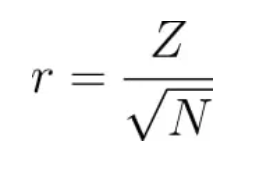
"

Источник - https://practicum.yandex.ru/blog/u-kriterii-manna-uitni/#prakticheskoye-primeneniye-testa-manna-uitni



In [ ]:
#попарный ман витней
pairs = list(itertools.combinations(areas, 2))
results = []

alpha = 0.05
k = len(pairs)

for a, b in pairs:
    x = groups[a]
    y = groups[b]

    U, p_raw = stats.mannwhitneyu(x, y, alternative="two-sided")

    #эффект размера r
    n1, n2 = len(x), len(y)
    mean_U = n1*n2/2
    std_U = np.sqrt(n1*n2*(n1+n2+1)/12)
    z = (U - mean_U) / std_U
    r = abs(z) / np.sqrt(n1 + n2)

    results.append({
        "group1": a,
        "group2": b,
        "U": U,
        "p_raw": p_raw,
        "p_corrected": p_raw * k,     #бонферрони
        "significant": p_raw * k < alpha,
        "effect_size_r": r
    })

pupupu_df = pd.DataFrame(results).sort_values("effect_size_r", ascending=False)
pupupu_df



,group1,group2,U,p_raw,p_corrected,significant,effect_size_r
35,ЗАО,ВАО,849151.0,1.111094e-26,3.999939e-25,True,0.219413
20,ЦАО,ВАО,2451278.5,6.589777e-29,2.372320e-27,True,0.155216
25,ЮЗАО,ВАО,819902.0,6.338549e-13,2.281878e-11,True,0.146026
28,ЮАО,ЗАО,659236.5,1.917049e-12,6.901375e-11,True,0.139899
34,СВАО,ВАО,317484.0,7.551767e-07,2.718636e-05,True,0.126523
31,САО,ЗАО,580467.5,1.013529e-09,3.648704e-08,True,0.125100
13,СЗАО,ЗАО,397974.0,1.127088e-07,4.057515e-06,True,0.116253
6,ЮВАО,ЗАО,454761.0,1.001290e-07,3.604646e-06,True,0.114337
32,САО,ВАО,501033.0,7.924818e-06,2.852934e-04,True,0.102660
7,ЮВАО,ВАО,388043.0,4.149407e-05,1.493786e-03,True,0.099992


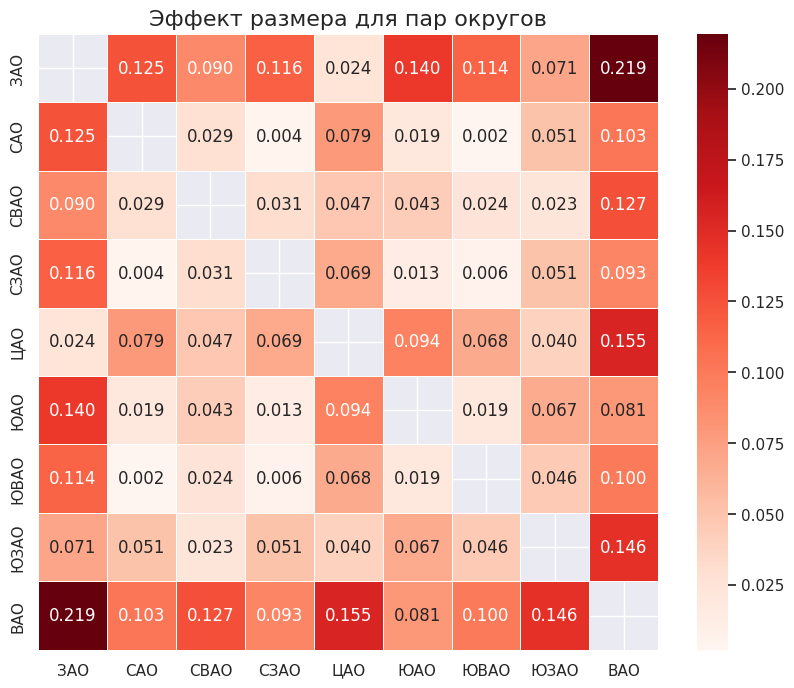

In [ ]:

df = pupupu_df.copy()

#создаём матрицу округов
areas = sorted(df["group1"].unique())
matrix = pd.DataFrame(index=areas, columns=areas, dtype=float)

#заполняем эффектами размера r
for _, row in df.iterrows():
    g1, g2, r = row["group1"], row["group2"], row["effect_size_r"]
    matrix.loc[g1, g2] = r
    matrix.loc[g2, g1] = r

#диагональ = 0
np.fill_diagonal(matrix.values, 0)

plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt=".3f", cmap="Reds", linewidths=.5)
plt.title("Эффект размера для пар округов", fontsize=16)
plt.show()


Итоги теста:

* Рейтинги врачей статистически различаются между округами Москвы, однако
величина различий крайне мала.

* Практически распределения оценок по округам похожи.

* Единственно заметная (но всё равно слабая) разница есть между Восточным округом и западными/центральными округами.

##ГИПОТЕЗА 2. Средняя цена врачей зависит от округа Москвы

H0: распределения цен одинаковы во всех округах

H1: хотя бы в одном округе цены отличаются

In [ ]:

df_price = data_moskow_okr[['area', 'price_avg']].copy()

#убираем строки где цена не число
df_price['price_avg'] = pd.to_numeric(df_price['price_avg'], errors='coerce')
df_price = df_price.dropna(subset=['area', 'price_avg'])

areas = df_price['area'].unique()

#каждому округу сопоставляем массив цен
groups_price = {
    area: df_price[df_price['area'] == area]['price_avg'].values.astype(float)
    for area in areas
}

df_price.shape


(6755, 2)

In [ ]:
df_price

,area,price_avg
0,ЮВАО,3500.0
1,СЗАО,5000.0
2,ЦАО,5500.0
3,ЮЗАО,6900.0
4,ЮАО,10000.0
...,...,...
36384,ЦАО,4565.0
36387,ЮАО,1775.0
36389,САО,10000.0
36390,ЦАО,3500.0


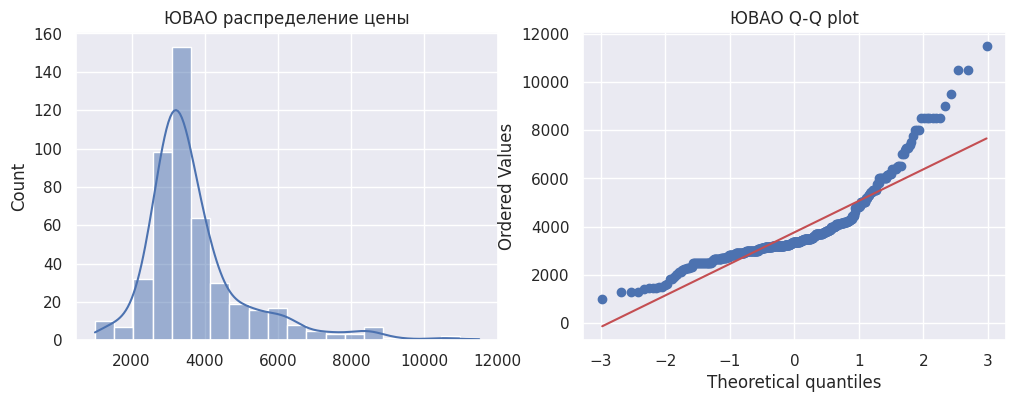

ЮВАО AD test=  AndersonResult(statistic=np.float64(28.390981666438506), critical_values=array([0.571, 0.651, 0.781, 0.91 , 1.083]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(3757.8867924528304), scale=np.float64(1448.8687110221463))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


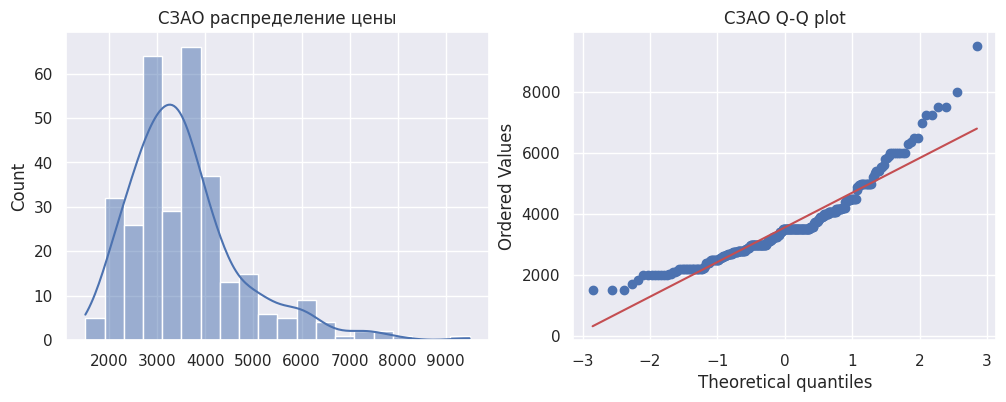

СЗАО AD test=  AndersonResult(statistic=np.float64(8.005021964813523), critical_values=array([0.569, 0.648, 0.777, 0.907, 1.079]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(3560.8616352201257), scale=np.float64(1189.378762386585))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


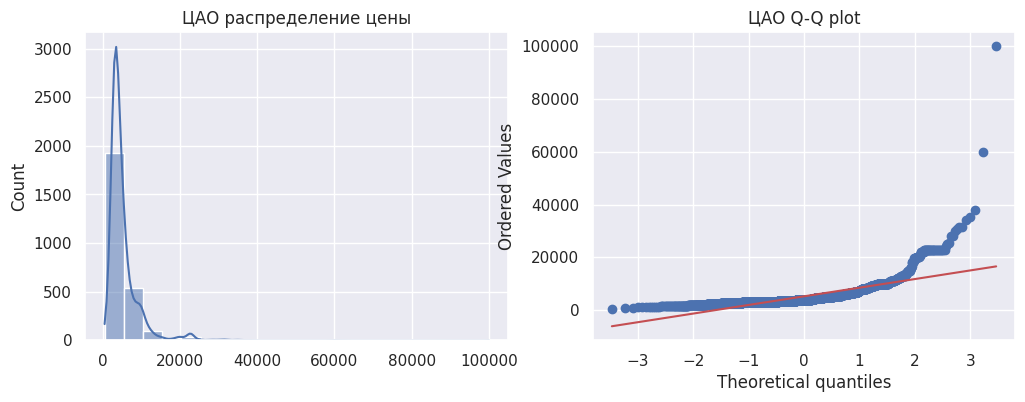

ЦАО AD test=  AndersonResult(statistic=np.float64(273.85238773737274), critical_values=array([0.575, 0.655, 0.786, 0.917, 1.09 ]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(5216.160212604404), scale=np.float64(4378.866117120231))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


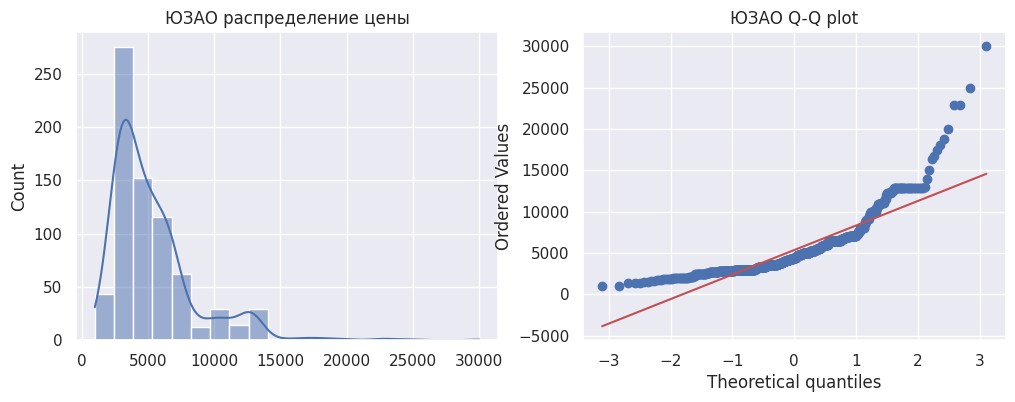

ЮЗАО AD test=  AndersonResult(statistic=np.float64(39.79867366294263), critical_values=array([0.573, 0.653, 0.783, 0.913, 1.086]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(5359.117092866756), scale=np.float64(3325.957578264692))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


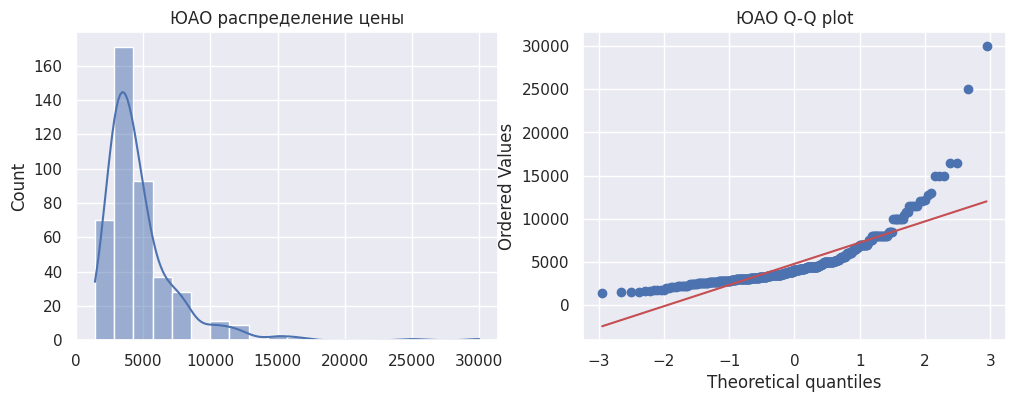

ЮАО AD test=  AndersonResult(statistic=np.float64(28.595859748625116), critical_values=array([0.571, 0.65 , 0.78 , 0.91 , 1.082]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(4768.68618266979), scale=np.float64(2913.2111648417917))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


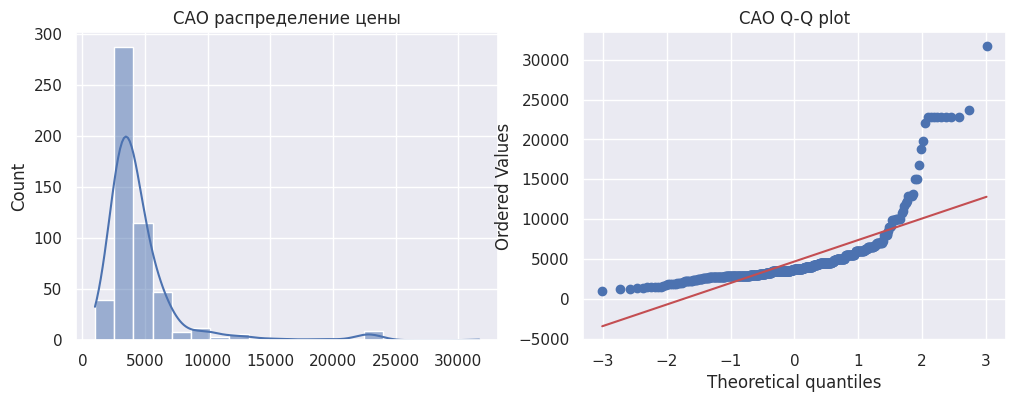

САО AD test=  AndersonResult(statistic=np.float64(65.61133285730943), critical_values=array([0.572, 0.651, 0.781, 0.911, 1.084]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(4696.235459662289), scale=np.float64(3570.0763711002555))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


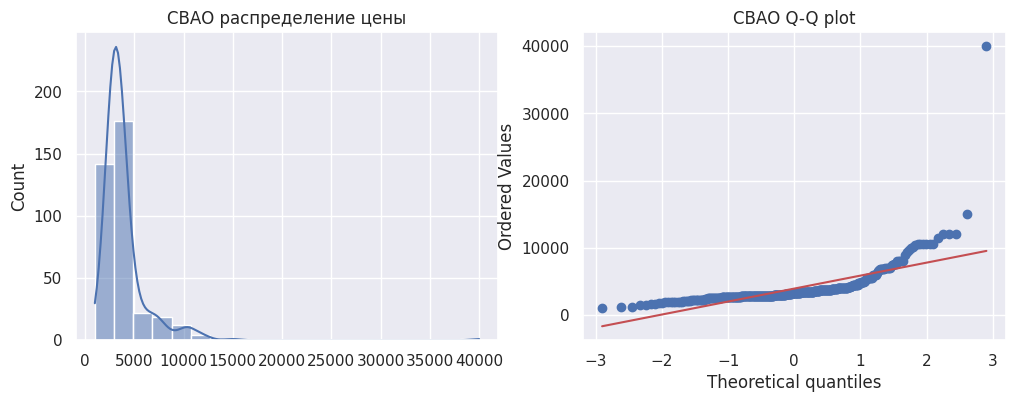

СВАО AD test=  AndersonResult(statistic=np.float64(44.904330568795956), critical_values=array([0.57 , 0.649, 0.779, 0.909, 1.081]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(3940.0954907161804), scale=np.float64(2714.705891980385))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


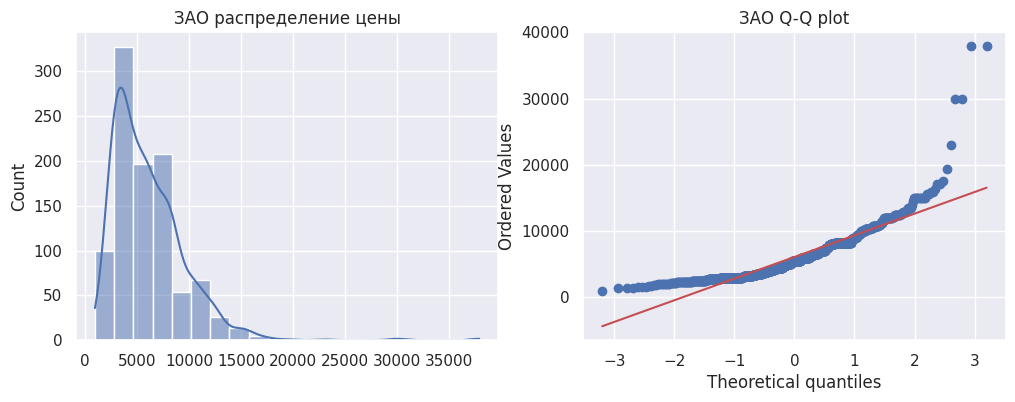

ЗАО AD test=  AndersonResult(statistic=np.float64(28.210558865864414), critical_values=array([0.574, 0.653, 0.784, 0.914, 1.088]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(6097.809072781655), scale=np.float64(3613.512460416356))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


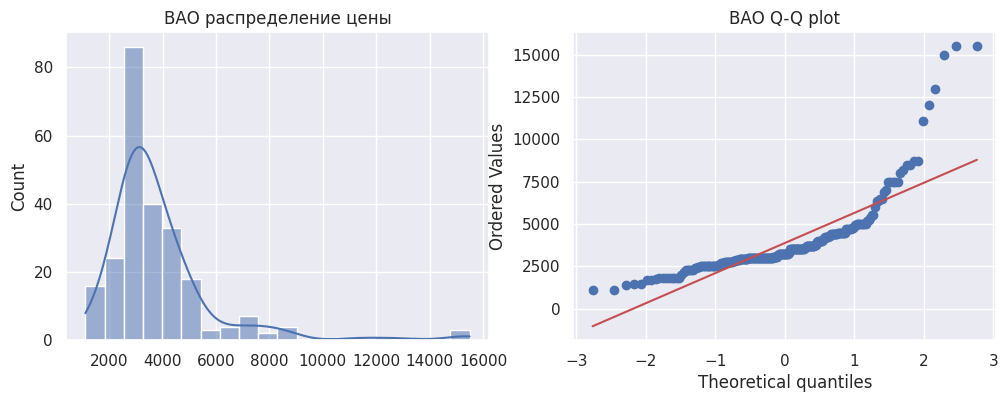

ВАО AD test=  AndersonResult(statistic=np.float64(19.27907583643821), critical_values=array([0.567, 0.646, 0.775, 0.904, 1.075]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(3869.1748971193415), scale=np.float64(2115.4703112246757))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


In [ ]:
for area in areas:
    data = groups_price[area]

    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    sns.histplot(data, kde=True, ax=ax[0], bins=20)
    ax[0].set_title(f"{area} распределение цены")

    stats.probplot(data, dist="norm", plot=ax[1])
    ax[1].set_title(f"{area} Q-Q plot")

    plt.show()


    #проверка нормальности
    print(area, "AD test= ", stats.anderson(data, dist='norm'))


In [ ]:
stats.levene(*groups_price.values(), center='median')


LeveneResult(statistic=np.float64(23.27927451759906), pvalue=np.float64(1.645097025939876e-35))

Распределения цен:

не нормальные

сильно разнятся дисперсии

поэтому используем непараметрические тесты

In [ ]:
stats.kruskal(*groups_price.values())


KruskalResult(statistic=np.float64(447.56475297046035), pvalue=np.float64(1.2294479063157533e-91))

In [ ]:

pairs = list(itertools.combinations(areas, 2))
results = []
alpha = 0.05
k = len(pairs)

for a, b in pairs:
    x = groups_price[a]
    y = groups_price[b]

    U, p_raw = stats.mannwhitneyu(x, y, alternative="two-sided")

    n1, n2 = len(x), len(y)
    mean_U = n1*n2/2
    std_U = np.sqrt(n1*n2*(n1+n2+1)/12)
    z = (U - mean_U) / std_U
    r = abs(z) / np.sqrt(n1 + n2)

    results.append({
        "group1": a,
        "group2": b,
        "U": U,
        "p_raw": p_raw,
        "p_corrected": p_raw * k,
        "significant": (p_raw * k) < alpha,
        "effect_size_r": r
    })

pupupu_df = pd.DataFrame(results).sort_values("p_corrected")
pupupu_df


,group1,group2,U,p_raw,p_corrected,significant,effect_size_r
6,ЮВАО,ЗАО,132697.0,1.035735e-43,3.728648e-42,True,0.360328
13,СЗАО,ЗАО,80047.5,5.787997e-41,2.083679e-39,True,0.368673
33,СВАО,ЗАО,102605.0,2.884995e-39,1.038598e-37,True,0.352818
35,ЗАО,ВАО,176540.5,1.652377e-27,5.948556e-26,True,0.307781
19,ЦАО,ЗАО,1032382.0,2.025559e-24,7.292013e-23,True,0.169075
31,САО,ЗАО,184823.0,2.062318e-23,7.424344e-22,True,0.254316
9,СЗАО,ЮЗАО,75401.5,8.740685e-21,3.146647e-19,True,0.286914
23,ЮЗАО,СВАО,186509.0,1.044845e-19,3.761441e-18,True,0.271351
18,ЦАО,СВАО,637524.0,4.122912e-19,1.484248e-17,True,0.162778
2,ЮВАО,ЮЗАО,123663.0,4.735900e-19,1.704924e-17,True,0.255269


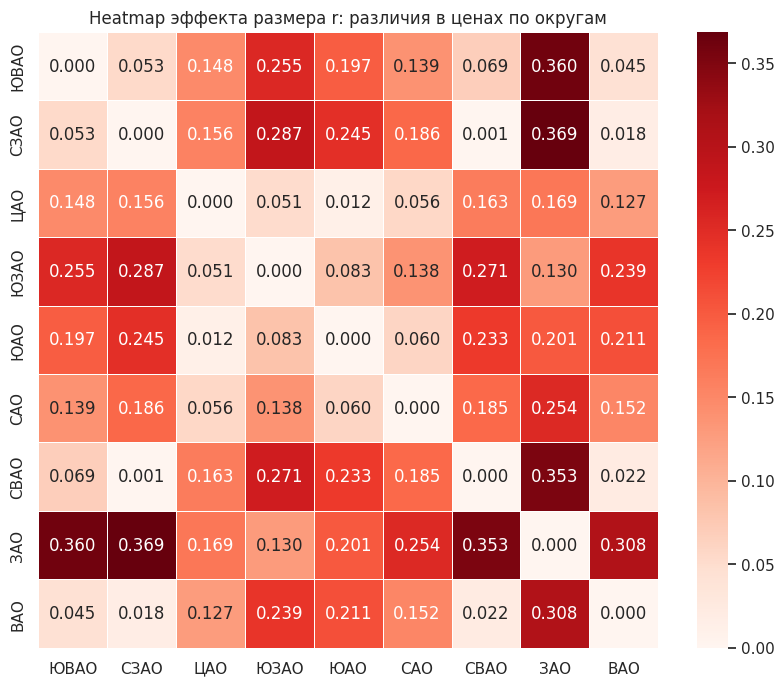

In [ ]:
#матрица округов
mat = pd.DataFrame(index=areas, columns=areas, dtype=float)

for _, row in pupupu_df.iterrows():
    g1, g2 = row["group1"], row["group2"]
    r = row["effect_size_r"]
    mat.loc[g1, g2] = r
    mat.loc[g2, g1] = r

np.fill_diagonal(mat.values, 0)

plt.figure(figsize=(10,8))
sns.heatmap(mat, annot=True, fmt=".3f", cmap="Reds", linewidths=.5)
plt.title("Heatmap эффекта размера r: различия в ценах по округам")
plt.show()


Цены статистически значимо различаются между округами Москвы

Попарные сравнения:
большинство пар округов значимо различаются по цене

самые большие различия и заметные эффекты размера r (0.25–0.36) есть между Западным округом и самыми бюджетными округами ( ЮВАО, СЗАО, СВАО)

Выводы:

Запад, Центр и Юго-Запад значительно дороже

ВАО, ЮВАО, СВАО, СЗАО - самые дешёвые

ГИПОТЕЗА 4: Cравнение рейтингов между районами Москвы

H0: распределение рейтингов одинаково во всех районах

H1: хотя бы в одном районе отличается

In [ ]:
df_r = data_moskow.dropna(subset=['district', 'rating'])

districts = df_r['district'].unique()

groups = {d: df_r[df_r['district'] == d]['rating'].values for d in districts}

groups

{'Нижегородский район': array([4.125     , 1.81903626, 4.51773029, 4.10258108, 4.94605695,
        4.15548603, 2.79958333, 3.89022373, 3.96890169, 2.09458488,
        3.61270034, 4.18436353, 4.7375    , 4.475     , 5.        ,
        3.21297233, 4.671875  , 4.72556822, 4.7010517 , 4.7375    ,
        4.04398678, 2.66666667, 1.81903626, 2.82639212, 2.33333333,
        4.51773029, 4.671875  , 4.10258108, 4.94605695, 4.15548603,
        4.        , 2.79958333, 3.89022373, 2.47338556, 0.57676053,
        2.09458488, 1.38333333, 4.37241053, 4.07380952, 3.61270034,
        4.18436353, 0.4965488 , 2.25      , 4.475     , 3.66666667,
        3.25      , 3.30529799, 4.33759593, 3.6       , 4.12582731,
        3.75      , 3.21297233, 4.90747078, 4.44938849, 2.75469157,
        4.72204102, 3.10035942, 0.2222709 , 0.21666667, 1.        ,
        3.33333333, 4.07341657, 2.75      , 3.17517971, 0.4965488 ,
        4.7010517 , 2.19098031, 3.36057508, 0.4965488 , 0.474968  ,
        2.25      , 1.747

In [ ]:
stats.kruskal(*groups.values())


KruskalResult(statistic=np.float64(923.9045861460302), pvalue=np.float64(7.598707362692553e-128))

У нас есть статестические основания отклонить нулевую гипотезу и сказать, что различия рейтингов между районами существуют

In [ ]:
results = []

for d1, d2 in combinations(districts, 2):
    data1 = groups[d1]
    data2 = groups[d2]


    U, p = stats.mannwhitneyu(data1, data2, alternative='two-sided')

    #Z-score
    n1, n2 = len(data1), len(data2)
    mean_U = n1 * n2 / 2
    std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (U - mean_U) / std_U

    #effect size r
    r = abs(z) / np.sqrt(n1 + n2)

    results.append([d1, d2, U, p, r])

df_pairs = pd.DataFrame(results,
                        columns=['district1', 'district2', 'U', 'p_raw', 'effect_size_r'])


df_pairs['p_corrected'] = df_pairs['p_raw'] * len(df_pairs)
df_pairs['significant'] = df_pairs['p_corrected'] < 0.05

df_pairs.sort_values('p_raw', inplace=True)
df_pairs.head(15)


,district1,district2,U,p_raw,effect_size_r,p_corrected,significant
1897,Тверской район,район Нагатино-Садовники,169817.0,7.862444e-37,0.403299,4.975355e-33,True
1480,район Беговой,Тверской район,55581.0,3.289271e-30,0.371697,2.081450e-26,True
1950,Тверской район,район Вешняки,88989.5,7.329020e-30,0.400792,4.637804e-26,True
238,Мещанский район,Тверской район,141205.0,1.409958e-27,0.299549,8.922217e-24,True
1948,Тверской район,район Новогиреево,39760.5,1.232576e-24,0.390053,7.799744e-21,True
1913,Тверской район,район Зюзино,89216.0,1.585085e-23,0.350790,1.003042e-19,True
1886,Тверской район,район Перово,119251.0,3.043468e-21,0.316604,1.925907e-17,True
1899,Тверской район,район Северное Тушино,44710.5,3.717616e-21,0.355541,2.352507e-17,True
1887,Тверской район,Можайский район,65696.5,6.555254e-21,0.340934,4.148165e-17,True
1896,Тверской район,район Марьино,68360.5,5.046030e-20,0.331291,3.193128e-16,True


In [ ]:
df_pairs.size

44296

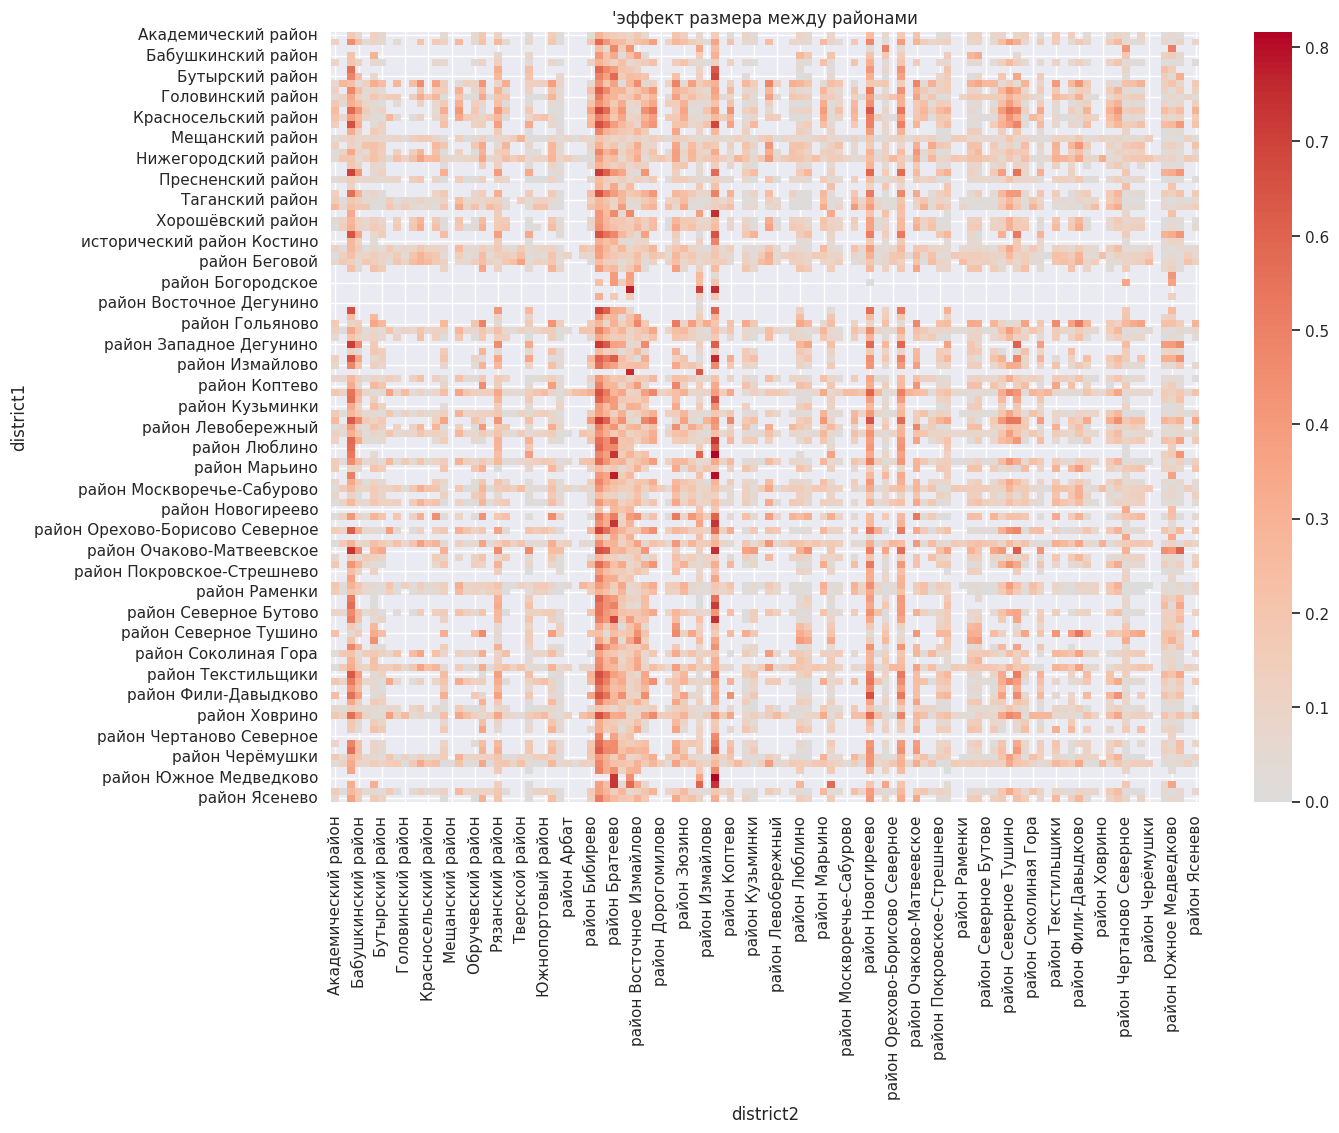

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df_pairs.pivot(index='district1', columns='district2', values='effect_size_r')

plt.figure(figsize=(14,10))
sns.heatmap(pivot, cmap='coolwarm', center=0, annot=False)
plt.title("'эффект размера между районами")
plt.show()


О как............

яркие красные блоки это районы центра, которые резко отличаются от других

Итоги
1) Значимых различий очень много, даже после строгой поправки Бонферрони
2) Для многих пар районов effect size r = 0.30–0.45, что считается средним и крупным эффектом.
3) Районы с наиболее выраженными отличиями (дорогие):

Тверской район

Мещанский район

Пресненский район

Беговой

Хамовники

4) Спальные районы образуют более однородную группу.


## ГИПОТЕЗА 3. Различаются ли рейтинги врачей между районами Москвы?

H0: рейтинги одинаковые во всех районах.

H1: хотя бы в одном районе рейтинги отличаются отличаются.


In [ ]:
#cчитаем количество врачей по районам чтоб огр сделать
district_counts = (
    df_r
    .groupby('district')
    .size()
    .rename('n_doctors')
)

district_counts.describe()

,n_doctors
count,113.000000
mean,107.230088
std,144.216480
min,1.000000
25%,19.000000
50%,54.000000
75%,147.000000
max,764.000000


In [ ]:
df_r = data_moskow.dropna(subset=['district', 'rating']).copy()

#оставляем только районы с >= 15 врачами
valid_districts = district_counts[district_counts >= 15].index

#фильтруем датафрейм
df_r = df_r[df_r['district'].isin(valid_districts)]

#формируем список районов и группы
districts = df_r['district'].unique()

groups = {
    d: df_r[df_r['district'] == d]['rating'].values
    for d in districts
}

#проверка
{d: len(v) for d, v in groups.items()}


{'Нижегородский район': 76,
 'район Щукино': 103,
 'Мещанский район': 703,
 'район Котловка': 53,
 'район Москворечье-Сабурово': 131,
 'район Аэропорт': 151,
 'район Отрадное': 61,
 'район Ховрино': 45,
 'район Солнцево': 70,
 'район Дорогомилово': 117,
 'район Лефортово': 168,
 'район Марьина Роща': 66,
 'район Проспект Вернадского': 243,
 'район Арбат': 212,
 'район Беговой': 329,
 'район Черёмушки': 224,
 'район Кунцево': 242,
 'Таганский район': 507,
 'Тверской район': 615,
 'Головинский район': 58,
 'район Раменки': 420,
 'район Якиманка': 203,
 'район Нагатинский Затон': 54,
 'Красносельский район': 120,
 'Пресненский район': 462,
 'район Орехово-Борисово Северное': 27,
 'район Коньково': 156,
 'район Соколиная Гора': 155,
 'район Хамовники': 764,
 'район Тропарёво-Никулино': 57,
 'Войковский район': 39,
 'район Северное Бутово': 27,
 'Южнопортовый район': 105,
 'Нагорный район': 30,
 'Хорошёвский район': 147,
 'район Новокосино': 15,
 'район Левобережный': 21,
 'Даниловский райо

In [ ]:
stats.kruskal(*groups.values())

KruskalResult(statistic=np.float64(875.5896473628214), pvalue=np.float64(5.073527352256992e-129))

p-value < 0.001, отклоняем H0

Различия между районами реально существуют

In [ ]:
results = []

for d1, d2 in combinations(districts, 2):
    data1 = groups[d1]
    data2 = groups[d2]

    U, p = stats.mannwhitneyu(data1, data2, alternative='two-sided')

    #Z-статистика
    n1, n2 = len(data1), len(data2)
    mean_U = n1 * n2 / 2
    std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (U - mean_U) / std_U

    #эффект размера r
    r = abs(z) / np.sqrt(n1 + n2)

    results.append([d1, d2, U, p, r])

df_pairs = pd.DataFrame(results,
                        columns=['district1', 'district2', 'U', 'p_raw', 'effect_size_r'])

#поправка бонферонни
df_pairs['p_corrected'] = df_pairs['p_raw'] * len(df_pairs)
df_pairs['significant'] = df_pairs['p_corrected'] < 0.05

df_pairs.sort_values('p_raw', inplace=True)
df_pairs.head(15)


,district1,district2,U,p_raw,effect_size_r,p_corrected,significant
1499,Тверской район,район Нагатино-Садовники,169817.0,7.862444e-37,0.403299,3.219671e-33,True
1172,район Беговой,Тверской район,55581.0,3.289271e-30,0.371697,1.346956e-26,True
1537,Тверской район,район Вешняки,88989.5,7.329020e-30,0.400792,3.001234e-26,True
194,Мещанский район,Тверской район,141205.0,1.409958e-27,0.299549,5.773780e-24,True
1535,Тверской район,район Новогиреево,39760.5,1.232576e-24,0.390053,5.047401e-21,True
1514,Тверской район,район Зюзино,89216.0,1.585085e-23,0.350790,6.490923e-20,True
1490,Тверской район,район Перово,119251.0,3.043468e-21,0.316604,1.246300e-17,True
1501,Тверской район,район Северное Тушино,44710.5,3.717616e-21,0.355541,1.522364e-17,True
1491,Тверской район,Можайский район,65696.5,6.555254e-21,0.340934,2.684376e-17,True
1498,Тверской район,район Марьино,68360.5,5.046030e-20,0.331291,2.066349e-16,True


In [ ]:
district_summary = (
    pd.concat([
        df_pairs[['district1', 'effect_size_r']]
            .rename(columns={'district1': 'district'}),
        df_pairs[['district2', 'effect_size_r']]
            .rename(columns={'district2': 'district'})
    ])
    .groupby('district')
    .agg(
        mean_effect_r=('effect_size_r', 'mean'),
        max_effect_r=('effect_size_r', 'max')
    )
    .sort_values('mean_effect_r', ascending=False)
)

district_summary.head(10)


,mean_effect_r,max_effect_r
district,,
район Бирюлёво Восточное,0.443082,0.719389
район Новогиреево,0.343889,0.657470
Алтуфьевский район,0.318506,0.712754
район Западное Дегунино,0.299973,0.717436
район Богородское,0.299185,0.629282
район Куркино,0.296118,0.710808
район Северное Тушино,0.284128,0.541289
район Орехово-Борисово Южное,0.275961,0.591367
Донской район,0.262950,0.684744


In [ ]:
#добавим рейтинги

district_rating_stats = (
    data_moskow
    .dropna(subset=['district', 'rating'])
    .groupby('district')
    .agg(
        mean_rating=('rating', 'mean'),
        median_rating=('rating', 'median'),
        n_doctors=('rating', 'count')
    )
)


In [ ]:
district_summary = (
    district_summary
    .merge(
        district_rating_stats,
        left_index=True,
        right_index=True,
        how='left'
    )
    .sort_values('mean_effect_r', ascending=False)
)

In [ ]:
district_summary.head()

,mean_effect_r,max_effect_r,mean_rating,median_rating,n_doctors
district,,,,,
район Бирюлёво Восточное,0.443082,0.719389,2.038370,1.874379,32
район Новогиреево,0.343889,0.657470,2.706046,3.250000,75
Алтуфьевский район,0.318506,0.712754,2.740585,2.762013,21
район Западное Дегунино,0.299973,0.717436,4.368253,4.562237,18
район Богородское,0.299185,0.629282,2.718682,2.979167,33


In [ ]:
district_summary.sort_values('median_rating', ascending=False)

,mean_effect_r,max_effect_r,mean_rating,median_rating,n_doctors
district,,,,,
район Западное Дегунино,0.299973,0.717436,4.368253,4.562237,18
район Куркино,0.296118,0.710808,4.259453,4.496921,44
Останкинский район,0.254156,0.719389,4.262403,4.475000,21
Донской район,0.262950,0.684744,4.211636,4.442112,53
район Текстильщики,0.218010,0.667228,4.161618,4.408102,23
...,...,...,...,...,...
район Гольяново,0.260613,0.553307,2.903264,3.250000,61
район Северное Тушино,0.284128,0.541289,2.824060,3.177083,90
район Богородское,0.299185,0.629282,2.718682,2.979167,33


Итоги:

1) Для большого числа пар районов p-value остаётся значимым даже после строгой поправки Бонферрони. Это даёт основания отклонить нулевую гипотезу и утверждать, что рейтинги врачей действительно различаются между районами Москвы.
2) Самые сильные различия в рейтингах врачей формируются не в центральных районах, а в отдельных спальных районах, которые либо системно отстают, либо системно превосходят средний уровень Москвы
3) Часть районов (Бирюлёво Восточное, Новогиреево, Алтуфьевский район) демонстрируют высокие значения effect size за счёт системно низких рейтингов врачей, что указывает на потенциальные проблемы в качестве медицинских услуг.
4) В то же время другие районы (Куркино, Останкинский, Донской) отличаются за счёт стабильно высоких оценок. Центральные районы Москвы не формируют экстремальных различий, несмотря на большое число врачей.

# ГИПОТЕЗА 4. Различаются ли цены врачей между районами Москвы

H0: цены одинаковы во всех районах

H1: хотя бы в одном районе цены отличаются

In [ ]:
df_price_d = data_moskow.dropna(subset=['district', 'price_avg']).copy()

df_price_d['price_avg'] = pd.to_numeric(df_price_d['price_avg'], errors='coerce')
df_price_d = df_price_d.dropna(subset=['price_avg'])

#фильтр чтобы врачей было не меньше 13 в районе
valid_districts_price = district_price_counts[district_price_counts >= 13].index
len(valid_districts_price)
df_price_d = df_price_d[df_price_d['district'].isin(valid_districts_price)]

districts = df_price_d['district'].unique()

groups_price = {
    d: df_price_d[df_price_d['district'] == d]['price_avg'].values
    for d in districts
}

len(districts)


NameError: name 'district_price_counts' is not defined

In [ ]:
stats.levene(*groups_price.values(), center='median')


In [ ]:
district_price_counts = (
    df_price_d
    .groupby('district')
    .size()
    .rename('n_doctors')
)

district_price_counts.describe()

Дисперсии различаются, параметрические тесты нельзя использовать

Посмотрим как выглядят распределения (некоторых районов, посомтрим пять)

In [ ]:
for d in districts[:5]:
    data = groups_price[d]
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    sns.histplot(data, kde=True, ax=ax[0])
    stats.probplot(data, dist="norm", plot=ax[1])
    ax[0].set_title(d)
    plt.show()


Распределние явно не нормальное, везде есть сдвиги правого хвоста длинные влево

Краскал Уоллис тест:

In [ ]:
stats.kruskal(*groups_price.values())


p-value меньше 0.05, H0 отклоняем

**Цены различаются между районами**

In [ ]:
results = []
alpha = 0.05
pairs = list(combinations(districts, 2))
k = len(pairs)

for d1, d2 in pairs:
    x = groups_price[d1]
    y = groups_price[d2]

    U, p_raw = stats.mannwhitneyu(x, y, alternative='two-sided')

    n1, n2 = len(x), len(y)
    mean_U = n1 * n2 / 2
    std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (U - mean_U) / std_U

    r = abs(z) / np.sqrt(n1 + n2)

    results.append({
        'district1': d1,
        'district2': d2,
        'U': U,
        'p_raw': p_raw,
        'p_corrected': p_raw * k,
        'significant': (p_raw * k) < alpha,
        'effect_size_r': r
    })

df_pairs_price = pd.DataFrame(results).sort_values('p_corrected')
df_pairs_price.head(100)


In [ ]:
df = df_pairs_price.copy()

district_stats = (
    pd.concat([
        df[['district1','effect_size_r']].rename(columns={'district1':'district'}),
        df[['district2','effect_size_r']].rename(columns={'district2':'district'})
    ])
    .groupby('district')
    .agg(
        mean_r=('effect_size_r','mean'),
        share_large_r=('effect_size_r', lambda x: (x > 0.5).mean()),
    )
    .sort_values('mean_r', ascending=False)
)

district_stats.head(10)


In [ ]:
district_price_stats = (
    df_price_d
    .groupby('district')
    .agg(
        mean_price=('price_avg', 'mean'),
        median_price=('price_avg', 'median'),
        n_doctors=('price_avg', 'count')
    )
)
district_price_stats

In [ ]:
district_price_summary = (
    district_stats
    .merge(
        district_price_stats,
        left_index=True,
        right_index=True,
        how='left'
    )
    .sort_values('mean_r', ascending=False)
)
district_price_summary.head(20)

In [ ]:
district_price_summary.sort_values('median_price', ascending=False)

In [ ]:
df_seg = district_price_summary.reset_index()[['district', 'mean_price']].copy()
df_seg = df_seg.sort_values('mean_price', ascending=False).reset_index(drop=True)

n = len(df_seg)

def get_segment(rank):
    pct = rank / n

    if rank == 0:
        return "Самый дорогой район Москвы"
    elif pct <= 0.05:
        return "Топ-5% самых дорогих районов"
    elif pct <= 0.10:
        return "Топ-10% самых дорогих районов"
    elif pct <= 0.25:
        return "Премиальный район"
    elif pct <= 0.45:
        return "Выше среднего по цене"
    elif pct <= 0.65:
        return "Средний ценовой сегмент"
    elif pct <= 0.80:
        return "Ниже среднего по цене"
    elif pct <= 0.90:
        return "Бюджетный район"
    elif pct <= 0.95:
        return "Топ-10% самых бюджетных районов"
    elif pct < 1.0:
        return "Топ-5% самых бюджетных районов"
    else:
        return "Самый бюджетный район Москвы"

df_seg['price_segment'] = [
    get_segment(i) for i in range(n)
]

# итоговый словарь
district_segment_dict = dict(
    zip(df_seg['district'], df_seg['price_segment'])
)

district_segment_dict


In [ ]:
district_price_summary

Выводы:

1) Различия цен между районами статистически значимы. Рынок медицинских услуг сильно территориально сегментирован по районам.

Для большого числа пар районов p-value остаётся значимым даже после строгой поправки Бонферрони

2) Есть Эффекты размера есть средние и даже крупные больше 0.5

3) Видно, что центральные престижные районы по типу Хамовников и Беговой резко отлечаются от спальних удаленных от центра.

**Беговой** — системно и резко выделяющийся премиальный ценовой район.

Контрастные из-за выоских цен (6 000–8 000+):
Беговой, Проспект Вернадского, Обручевский, Черёмушки, Раменки

Контрастные из-за низких цен (2 700–3 000):
Митино, Марьино, Гольяново, Текстильщики, Солнцево

4) Ценовая сегментация по районам выражена сильнее, чем сегментация по рейтингам.
Основные различия формируются за счёт сочетания:
нескольких премиальных районов и большого числа бюджетных районов.